<a href="https://colab.research.google.com/github/Kanikameister/predictive-credit-risk-engine/blob/main/credit_risk_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Predictive Credit Risk & Regression Engine

### Objective

Build an end-to-end machine learning pipeline to predict customer credit
card payment default using Python, Pandas, and Scikit-Learn.

### Dataset

UCI Default of Credit Card Clients Dataset

### Technologies

- Python
- Pandas
- NumPy
- Scikit-Learn
- Matplotlib
- Seaborn
- Statsmodels


In [1]:
!pip install ucimlrepo

In [2]:
import pandas as pd
import numpy as np

from ucimlrepo import fetch_ucirepo

## Milestone 1 — Data Loading & Initial Inspection

### 1.1 Import Required Libraries
- Import Pandas
- Import NumPy
- Import the UCI dataset retrieval package

### 1.2 Load the UCI Credit Card Default Dataset
- Fetch the UCI Default of Credit Card Clients dataset
- Separate predictor variables from the target variable
- Combine features and target into a single DataFrame

### 1.3 Inspect Dataset Dimensions
- Check the number of observations
- Check the number of predictor variables
- Verify the combined dataset dimensions

### 1.4 Inspect Variable Names
- Display all feature names
- Identify the target variable
- Review the original X1–X23 variable structure

### 1.5 Examine Data Types
- Check the data type of each variable
- Identify numerical and coded categorical variables

### 1.6 Generate Descriptive Statistics
- Calculate count, mean, standard deviation, minimum, quartiles, and maximum
- Review the overall numerical characteristics of the dataset

### 1.7 Check for Missing Values
- Calculate missing values for each variable
- Determine whether missing-value treatment is required

### 1.8 Check for Duplicate Records
- Identify duplicate observations
- Record the number of duplicate rows for later investigation

### 1.9 Examine Target Distribution
- Identify the target variable
- Count observations in each target class
- Calculate the percentage of each class
- Identify potential class imbalance

### 1.10 Milestone 1 Findings
- Document dataset size and structure
- Summarize data types and initial data quality
- Report missing values and duplicate records
- Report target-class distribution
- Identify issues requiring investigation in subsequent milestones

In [3]:
credit_data = fetch_ucirepo(id=350)

In [4]:
x = credit_data.data.features
y = credit_data.data.targets

In [5]:
print("Features: ", x.shape)
print("Targets: ", y.shape)

Features:  (30000, 23)
Targets:  (30000, 1)


In [6]:
df = pd.concat([x,y], axis=1)

In [7]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [8]:
print(df.columns.tolist())

['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'Y']


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  int64
 23  Y       300

In [10]:
df.describe().T # T transposes the table

,count,mean,std,min,25%,50%,75%,max
X1,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
X2,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
X3,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
X4,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
X5,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
X6,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
X7,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
X8,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
X9,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
X10,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


In [11]:
df.isnull().sum()

,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
X9,0
X10,0


In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 35


In [13]:
print(y.columns)

Index(['Y'], dtype='object')


In [14]:
y['Y'].value_counts()

,count
Y,
0,23364
1,6636


In [15]:
y['Y'].value_counts(normalize=True)*100

,proportion
Y,
0,77.88
1,22.12


### Milestone 1 Summary

The UCI Default of Credit Card Clients dataset was successfully imported
into Python using the `ucimlrepo` package.

Initial inspection included:

- Dataset dimensions
- Feature and target separation
- Variable names
- Data types
- Descriptive statistics
- Missing-value inspection
- Duplicate-row inspection
- Target-class distribution

Further data cleaning, exploratory analysis, multicollinearity analysis,
feature scaling, and predictive modeling will be completed in subsequent
milestones.

## Milestone 2 - Data Cleaning & Exploratory Data Analysis

1. **Understand Dataset Variables**
   - Review the meaning, measurement, and coding of all X1–X23 variables.
   - Identify numerical, categorical, and coded variables.

2. **Investigate Duplicate Records**
   - Identify duplicate rows.
   - Examine duplicate records before deciding whether to remove them.

3. **Verify Target Variable**
   - Confirm `Y` as the target variable.
   - Examine the distribution of default vs. non-default observations.

4. **Rename Variables**
   - Replace generic X1–X23 and Y labels with meaningful variable names.

5. **Verify Data Structure**
   - Confirm dimensions, column names, data types, and overall dataset integrity after renaming.

6. **Examine Categorical Variables**
   - Investigate `sex`, `education`, and `marital_status` coding and distributions.

7. **Examine Repayment History**
   - Analyze the six monthly repayment-status variables.
   - Investigate special codes such as `-2`, `-1`, and `0`.

8. **Examine Billing & Payment Variables**
   - Analyze monthly bill amounts and payment amounts.
   - Identify distributions, zeros, and potential outliers.

9. **Check Missing Values**
   - Confirm the presence or absence of missing data.

10. **Finalize Data Preparation Decisions**
    - Document decisions regarding duplicates, categorical coding, special repayment-status codes, and potential data-quality issues.

In [16]:
pd.set_option('display.max_rows', 30)

df.describe().T

,count,mean,std,min,25%,50%,75%,max
X1,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
X2,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
X3,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
X4,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
X5,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
X6,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
X7,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
X8,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
X9,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
X10,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


### X6–X11: Repayment History

Variables X6–X11 represent the customer's repayment status over six
consecutive months, from September 2005 through April 2005.

The UCI dataset defines the repayment-status scale as:

- `-1`: payment made duly/on time
- `1`: payment delayed by one month
- `2`: payment delayed by two months
- ...
- `8`: payment delayed by eight months
- `9`: payment delayed by nine months or more

The dataset also contains `-2` and `0` values. These special codes require
additional investigation before modeling rather than being treated as
ordinary continuous numerical values.

Because repayment history is directly related to a customer's recent
payment behaviour, X6–X11 will be examined as important predictors of
future default.

In [17]:
print("Target counts:")
print(y['Y'].value_counts().sort_index())

print("\nTarget value counts:")
print((y['Y'].value_counts(normalize=True).sort_index()*100).round(2))

Target counts:
Y
0    23364
1     6636
Name: count, dtype: int64

Target value counts:
Y
0    77.88
1    22.12
Name: proportion, dtype: float64


### Target Variable Analysis

The target variable `Y` represents whether a customer defaulted on their
credit card payment in the following month.

- `Y = 0`: No default
- `Y = 1`: Default

The dataset contains 30,000 observations. Of these, 23,364 customers
(77.88%) did not default, while 6,636 customers (22.12%) defaulted.

This indicates a class imbalance in the target variable. Therefore, model
performance will not be evaluated using accuracy alone. Precision, recall,
F1-score, ROC-AUC, and the confusion matrix will also be examined.

In [18]:
duplicates = df[df.duplicated(keep=False)]

print("Nume=ber of duplicate rows:", len(duplicates))
duplicates.head(20)

Nume=ber of duplicate rows: 70


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
18,360000,2,1,1,49,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
627,230000,1,1,1,39,-1,-1,-1,-1,-1,...,660,660,660,660,660,660,660,660,660,0
839,500000,1,1,1,43,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,1
1093,360000,1,2,1,41,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,1
1211,160000,2,3,2,26,-1,-1,-1,-1,-1,...,390,390,390,390,390,390,390,390,390,0
1601,150000,2,1,1,31,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
1759,50000,1,2,2,26,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
1964,150000,2,1,1,38,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,1
1980,150000,2,1,1,38,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,1
2621,210000,2,1,2,39,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0


In [19]:
duplicates['Y'].value_counts()

,count
Y,
0,58
1,12


In [20]:
duplicates.groupby('Y').size()

,0
Y,
0,58
1,12


In [21]:
df = df.rename(columns =
    {'X1': 'credit_limit',
    'X2': 'sex',
    'X3': 'education',
    'X4': 'marital_status',
    'X5': 'age',
    'X6': 'repay_sep',
    'X7': 'repay_aug',
    'X8': 'repay_jul',
    'X9': 'repay_jun',
    'X10': 'repay_may',
    'X11': 'repay_apr',
    'X12': 'bill_amt_sep',
    'X13': 'bill_amt_aug',
    'X14': 'bill_amt_jul',
    'X15': 'bill_amt_jun',
    'X16': 'bill_amt_may',
    'X17': 'bill_amt_apr',
    'X18': 'pay_amt_sep',
    'X19': 'pay_amt_aug',
    'X20': 'pay_amt_jul',
    'X21': 'pay_amt_jun',
    'X22': 'pay_amt_may',
    'X23': 'pay_amt_apr',
    'Y': 'default_next_month'})

In [22]:
df.columns

Index(['credit_limit', 'sex', 'education', 'marital_status', 'age',
       'repay_sep', 'repay_aug', 'repay_jul', 'repay_jun', 'repay_may',
       'repay_apr', 'bill_amt_sep', 'bill_amt_aug', 'bill_amt_jul',
       'bill_amt_jun', 'bill_amt_may', 'bill_amt_apr', 'pay_amt_sep',
       'pay_amt_aug', 'pay_amt_jul', 'pay_amt_jun', 'pay_amt_may',
       'pay_amt_apr', 'default_next_month'],
      dtype='object')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   credit_limit        30000 non-null  int64
 1   sex                 30000 non-null  int64
 2   education           30000 non-null  int64
 3   marital_status      30000 non-null  int64
 4   age                 30000 non-null  int64
 5   repay_sep           30000 non-null  int64
 6   repay_aug           30000 non-null  int64
 7   repay_jul           30000 non-null  int64
 8   repay_jun           30000 non-null  int64
 9   repay_may           30000 non-null  int64
 10  repay_apr           30000 non-null  int64
 11  bill_amt_sep        30000 non-null  int64
 12  bill_amt_aug        30000 non-null  int64
 13  bill_amt_jul        30000 non-null  int64
 14  bill_amt_jun        30000 non-null  int64
 15  bill_amt_may        30000 non-null  int64
 16  bill_amt_apr        30000 non-null  int6

In [24]:
df.head()

,credit_limit,sex,education,marital_status,age,repay_sep,repay_aug,repay_jul,repay_jun,repay_may,...,bill_amt_jun,bill_amt_may,bill_amt_apr,pay_amt_sep,pay_amt_aug,pay_amt_jul,pay_amt_jun,pay_amt_may,pay_amt_apr,default_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [25]:
for col in ['sex', 'education', 'marital_status']:
    print(df[col].value_counts().sort_index())
    print('\n')

sex
1    11888
2    18112
Name: count, dtype: int64


education
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64


marital_status
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64




In [26]:
for col in ['repay_sep', 'repay_aug', 'repay_jul',
    'repay_jun', 'repay_may', 'repay_apr']:
    print(df[col].value_counts().sort_index())
    print('\n')

repay_sep
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64


repay_aug
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64


repay_jul
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64


repay_jun
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64


repay_may
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64


repay_apr
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int64




In [27]:
bill_cols = ['bill_amt_sep', 'bill_amt_aug', 'bill_amt_jul', 'bill_amt_jun', 'bill_amt_may', 'bill_amt_apr']
df[bill_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
bill_amt_sep,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
bill_amt_aug,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
bill_amt_jul,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
bill_amt_jun,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
bill_amt_may,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
bill_amt_apr,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0


In [28]:
pay_cols = ['pay_amt_sep', 'pay_amt_aug', 'pay_amt_jul', 'pay_amt_jun', 'pay_amt_may', 'pay_amt_apr']
df[pay_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
pay_amt_sep,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0
pay_amt_aug,30000.0,5921.163500,23040.870402,0.0,833.00,2009.0,5000.00,1684259.0
pay_amt_jul,30000.0,5225.681500,17606.961470,0.0,390.00,1800.0,4505.00,896040.0
pay_amt_jun,30000.0,4826.076867,15666.159744,0.0,296.00,1500.0,4013.25,621000.0
pay_amt_may,30000.0,4799.387633,15278.305679,0.0,252.50,1500.0,4031.50,426529.0
pay_amt_apr,30000.0,5215.502567,17777.465775,0.0,117.75,1500.0,4000.00,528666.0


In [29]:
df.isnull().sum()

,0
credit_limit,0
sex,0
education,0
marital_status,0
age,0
repay_sep,0
repay_aug,0
repay_jul,0
repay_jun,0
repay_may,0


In [30]:
df.isnull().sum().sum()

np.int64(0)

In [31]:
df.duplicated().sum()

np.int64(35)

In [32]:
df['default_next_month'].value_counts()

,count
default_next_month,
0,23364
1,6636


In [33]:
df['default_next_month'].value_counts(normalize=True) * 100

,proportion
default_next_month,
0,77.88
1,22.12


### Milestone 2 Summary

The dataset was further examined to understand variable definitions,
categorical coding, repayment history, billing amounts, payment amounts,
duplicate records, missing values, and target-class distribution.

The original X1–X23 variables were renamed using descriptive feature names
to improve interpretability and readability. Categorical variables and
repayment-status variables were identified as coded variables requiring
careful treatment during preprocessing.

Duplicate records and special repayment-status codes were investigated
before making data-cleaning decisions. The target variable,
`default_next_month`, was confirmed as a binary classification target with
an imbalanced class distribution.

These findings will guide the exploratory data analysis and preprocessing
steps in the next milestone.

## Milestone 3 — Exploratory Data Analysis (EDA)

1. **Univariate Analysis**
   - Examine the distribution of individual numerical and categorical variables.
   - Identify central tendency, spread, skewness, and unusual values.

2. **Target Variable Analysis**
   - Visualize the distribution of `default_next_month`.
   - Assess the degree of class imbalance.

3. **Credit Limit and Demographic Analysis**
   - Analyze `credit_limit` and `age`.
   - Examine the distributions of `sex`, `education`, and `marital_status`.

4. **Repayment History Analysis**
   - Examine repayment-status patterns across the six months.
   - Identify trends and potential indicators of default risk.

5. **Billing and Payment Analysis**
   - Analyze monthly billing amounts and payment amounts.
   - Identify distributions, extreme values, and potential outliers.

6. **Bivariate Analysis**
   - Compare key features with `default_next_month`.
   - Examine differences in default rates across relevant groups.

7. **Correlation Analysis**
   - Calculate correlations among numerical variables.
   - Visualize relationships using a correlation matrix/heatmap.

8. **Multicollinearity Investigation**
   - Identify highly correlated predictor variables.
   - Calculate Variance Inflation Factor (VIF) for numerical predictors.

9. **EDA Findings & Feature Insights**
   - Summarize important patterns, relationships, outliers, and potential predictive features.
   - Document findings that will guide preprocessing and model development.

In [34]:
df. describe().T

,count,mean,std,min,25%,50%,75%,max
credit_limit,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
sex,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
education,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
marital_status,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
age,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
repay_sep,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
repay_aug,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
repay_jul,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
repay_jun,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
repay_may,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


In [35]:
numerical_cols = df.select_dtypes(include='number').columns

df[numerical_cols].skew().sort_values(ascending=False)

,0
pay_amt_aug,30.453817
pay_amt_jul,17.216635
pay_amt_sep,14.668364
pay_amt_jun,12.904985
pay_amt_may,11.127417
pay_amt_apr,10.640727
bill_amt_jul,3.087830
bill_amt_may,2.876380
bill_amt_apr,2.846645
bill_amt_jun,2.821965


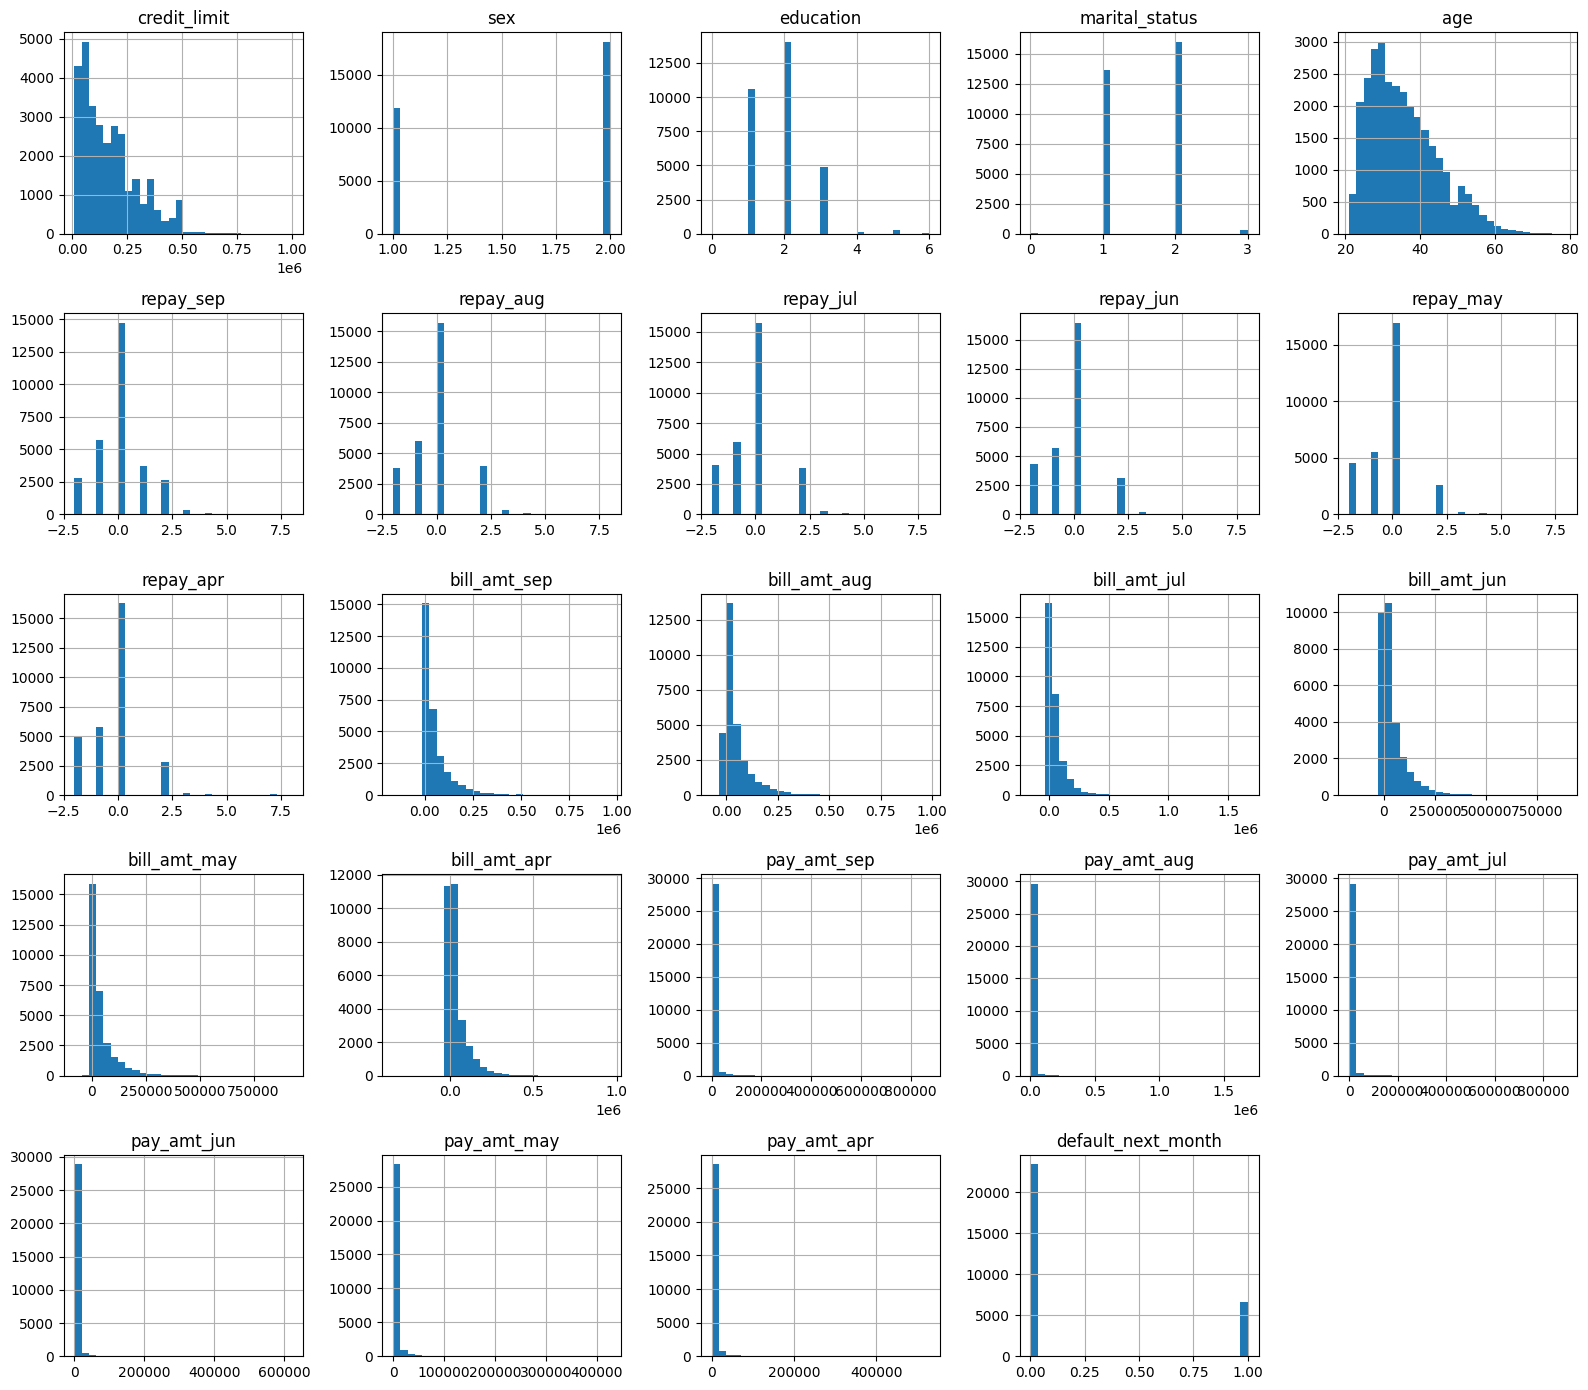

In [36]:
import matplotlib.pyplot as plt

df[numerical_cols].hist(bins=30, figsize=(16, 14))

plt.tight_layout()
plt.show()

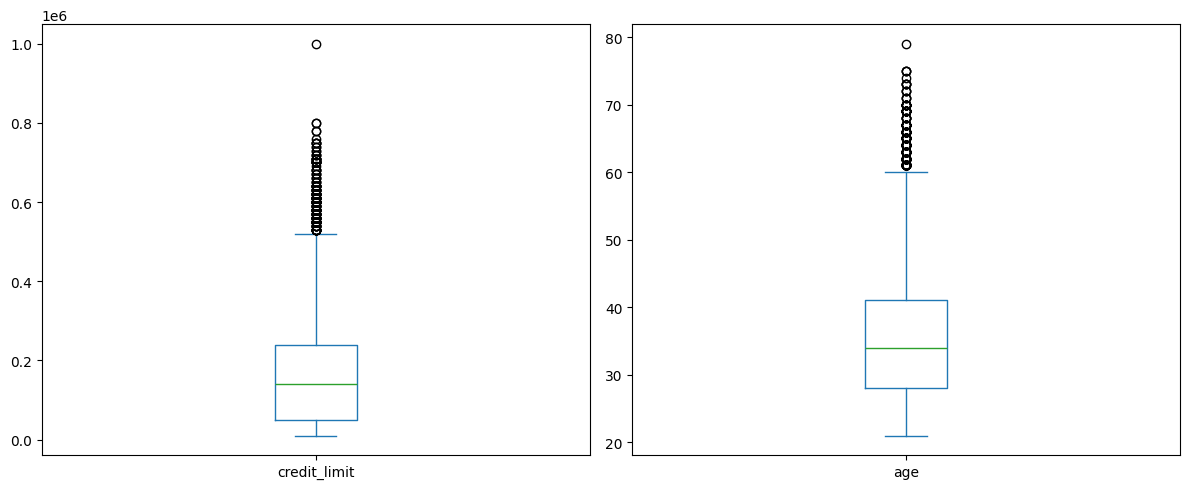

In [37]:
df[['credit_limit', 'age']].plot(kind='box', subplots = True, layout = (1,2), figsize=(12, 5))

plt.tight_layout()
plt.show()

In [38]:
df['default_next_month'].value_counts(normalize=True)

,proportion
default_next_month,
0,0.7788
1,0.2212


In [39]:
df['default_next_month'].value_counts(normalize=True) * 100

,proportion
default_next_month,
0,77.88
1,22.12


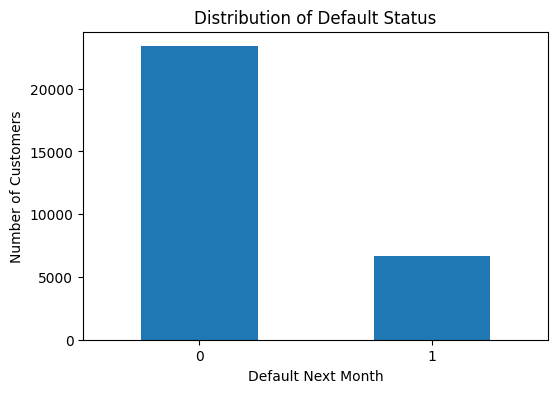

In [40]:
df['default_next_month'].value_counts().plot(kind = 'bar', figsize = (6,4))

plt.xlabel('Default Next Month')
plt.ylabel('Number of Customers')
plt.title('Distribution of Default Status')
plt.xticks(rotation=0)
plt.show()

In [41]:
df['credit_limit'].describe()

,credit_limit
count,30000.000000
mean,167484.322667
std,129747.661567
min,10000.000000
25%,50000.000000
50%,140000.000000
75%,240000.000000
max,1000000.000000


<function matplotlib.pyplot.show(close=None, block=None)>

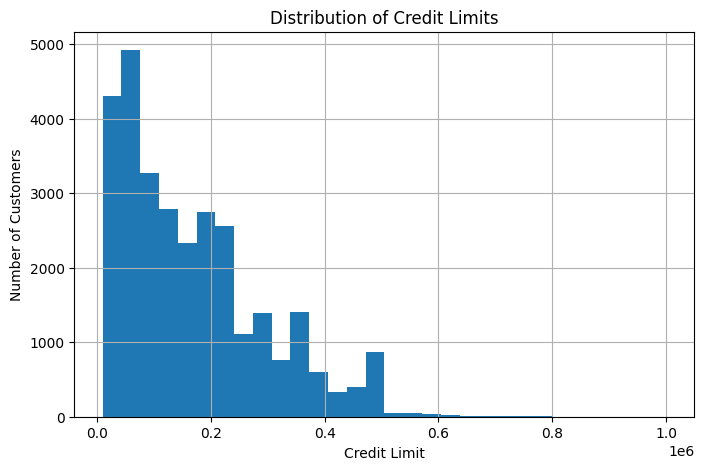

In [42]:
df['credit_limit'].hist(bins=30, figsize=(8,5))
plt.xlabel('Credit Limit')
plt.ylabel('Number of Customers')
plt.title('Distribution of Credit Limits')
plt.show

In [43]:
df['age'].describe()

,age
count,30000.000000
mean,35.485500
std,9.217904
min,21.000000
25%,28.000000
50%,34.000000
75%,41.000000
max,79.000000


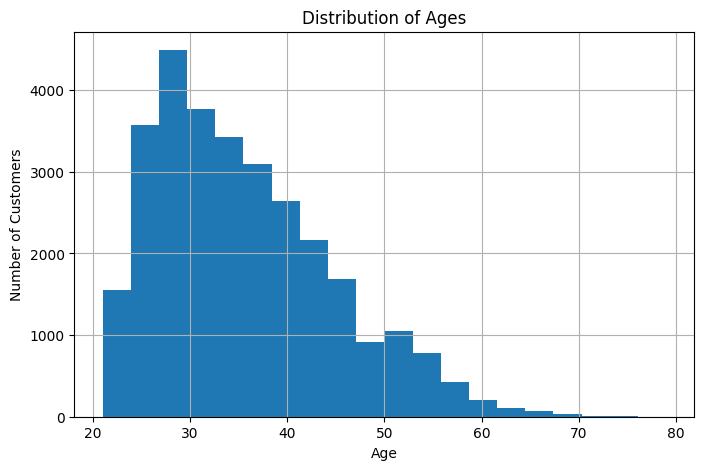

In [44]:
df['age'].hist(bins=20, figsize=(8,5))

plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.title('Distribution of Ages')
plt.show()

In [45]:
categorical_cols = ['sex', 'education', 'marital_status']

for col in categorical_cols:
    print(df[col].value_counts().sort_index())
    print('\n')

sex
1    11888
2    18112
Name: count, dtype: int64


education
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64


marital_status
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64




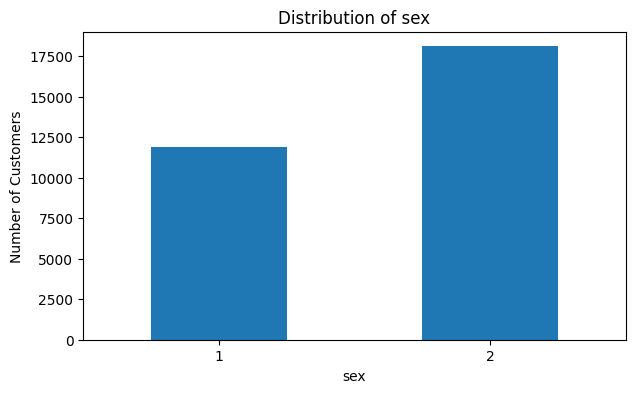

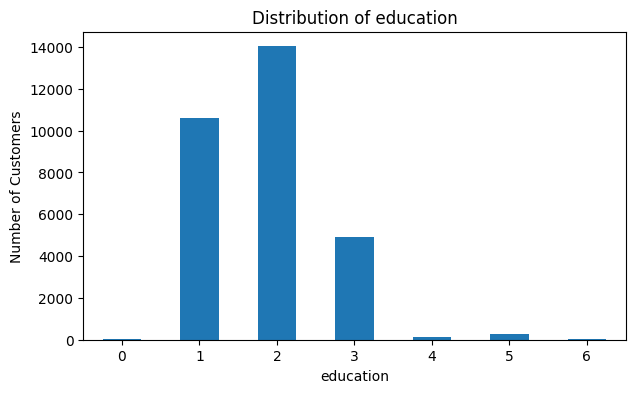

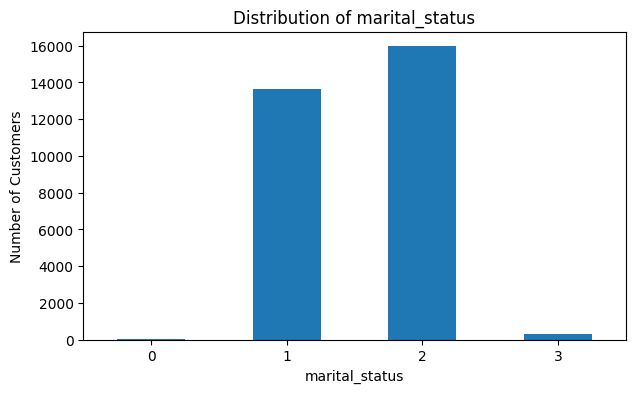

In [46]:
for col in categorical_cols:
  df[col].value_counts().sort_index().plot(kind = 'bar', figsize = (7,4))

  plt.xlabel(col)
  plt.ylabel('Number of Customers')
  plt.title(f'Distribution of {col}')
  plt.xticks(rotation=0)
  plt.show()

In [47]:
repay_cols = ['repay_sep', 'repay_aug', 'repay_jul', 'repay_jun', 'repay_may', 'repay_apr']

for col in repay_cols:
  print(df[col].value_counts().sort_index())
  print('\n')

repay_sep
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64


repay_aug
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64


repay_jul
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64


repay_jun
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64


repay_may
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64


repay_apr
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int64




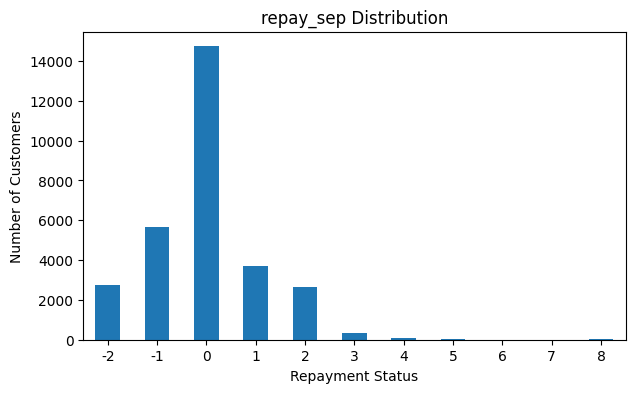

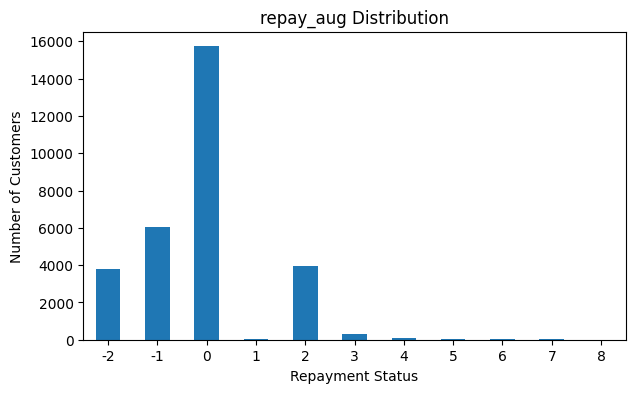

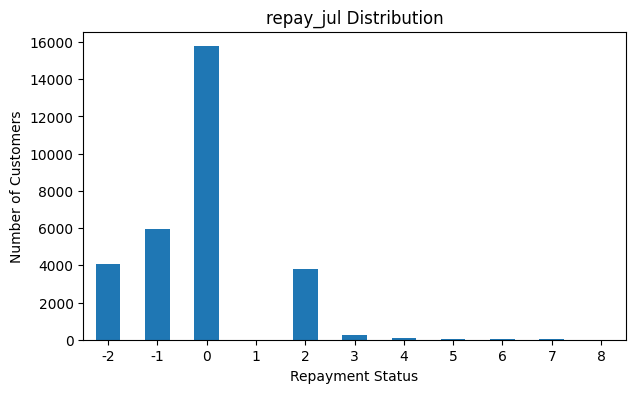

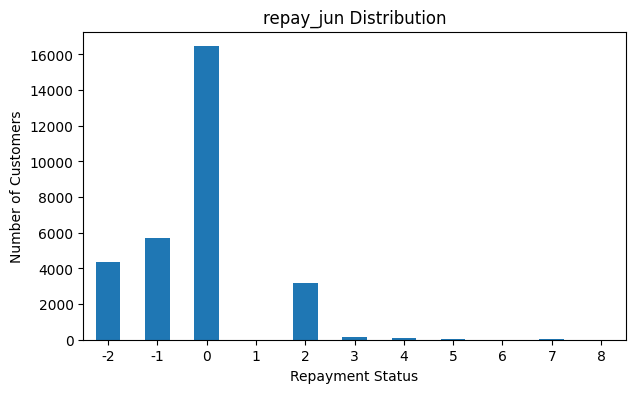

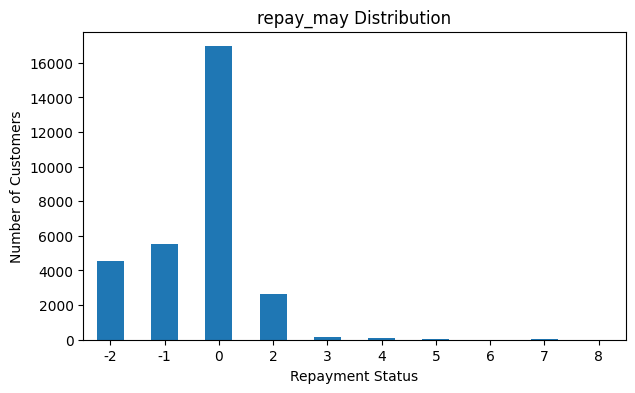

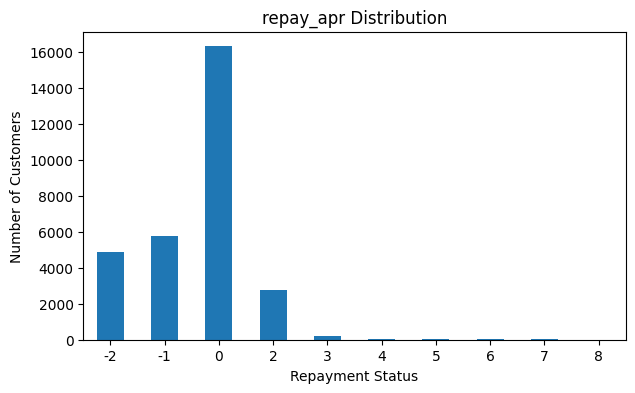

In [48]:
for col in repay_cols:
  df[col].value_counts().sort_index().plot(kind = 'bar', figsize = (7,4))

  plt.xlabel('Repayment Status')
  plt.ylabel('Number of Customers')
  plt.title(f'{col} Distribution')
  plt.xticks(rotation=0)
  plt.show()

In [49]:
for col in repay_cols:
  print(pd.crosstab(df['default_next_month'], df[col], normalize='index') * 100)
  print('\n')

repay_sep                  -2         -1          0          1          2  \
default_next_month                                                          
0                   10.246533  20.253381  54.994864  10.426297   3.522513   
1                    5.500301  14.376130  28.450874  18.866787  27.787824   

repay_sep                  3         4         5         6         7         8  
default_next_month                                                              
0                   0.333847  0.102722  0.055641  0.021400  0.008560  0.034241  
1                   3.676914  0.783605  0.195901  0.090416  0.105485  0.165763  


repay_aug                  -2         -1          0         1          2  \
default_next_month                                                         
0                   13.229755  21.759973  56.612738  0.098442   7.460195   
1                   10.412899  14.556962  37.718505  0.075347  32.911392   

repay_aug                  3         4         5         6  

In [50]:
bill_cols = ['bill_amt_sep', 'bill_amt_aug', 'bill_amt_jul', 'bill_amt_jun', 'bill_amt_may', 'bill_amt_apr']

df[bill_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
bill_amt_sep,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
bill_amt_aug,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
bill_amt_jul,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
bill_amt_jun,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
bill_amt_may,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
bill_amt_apr,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0


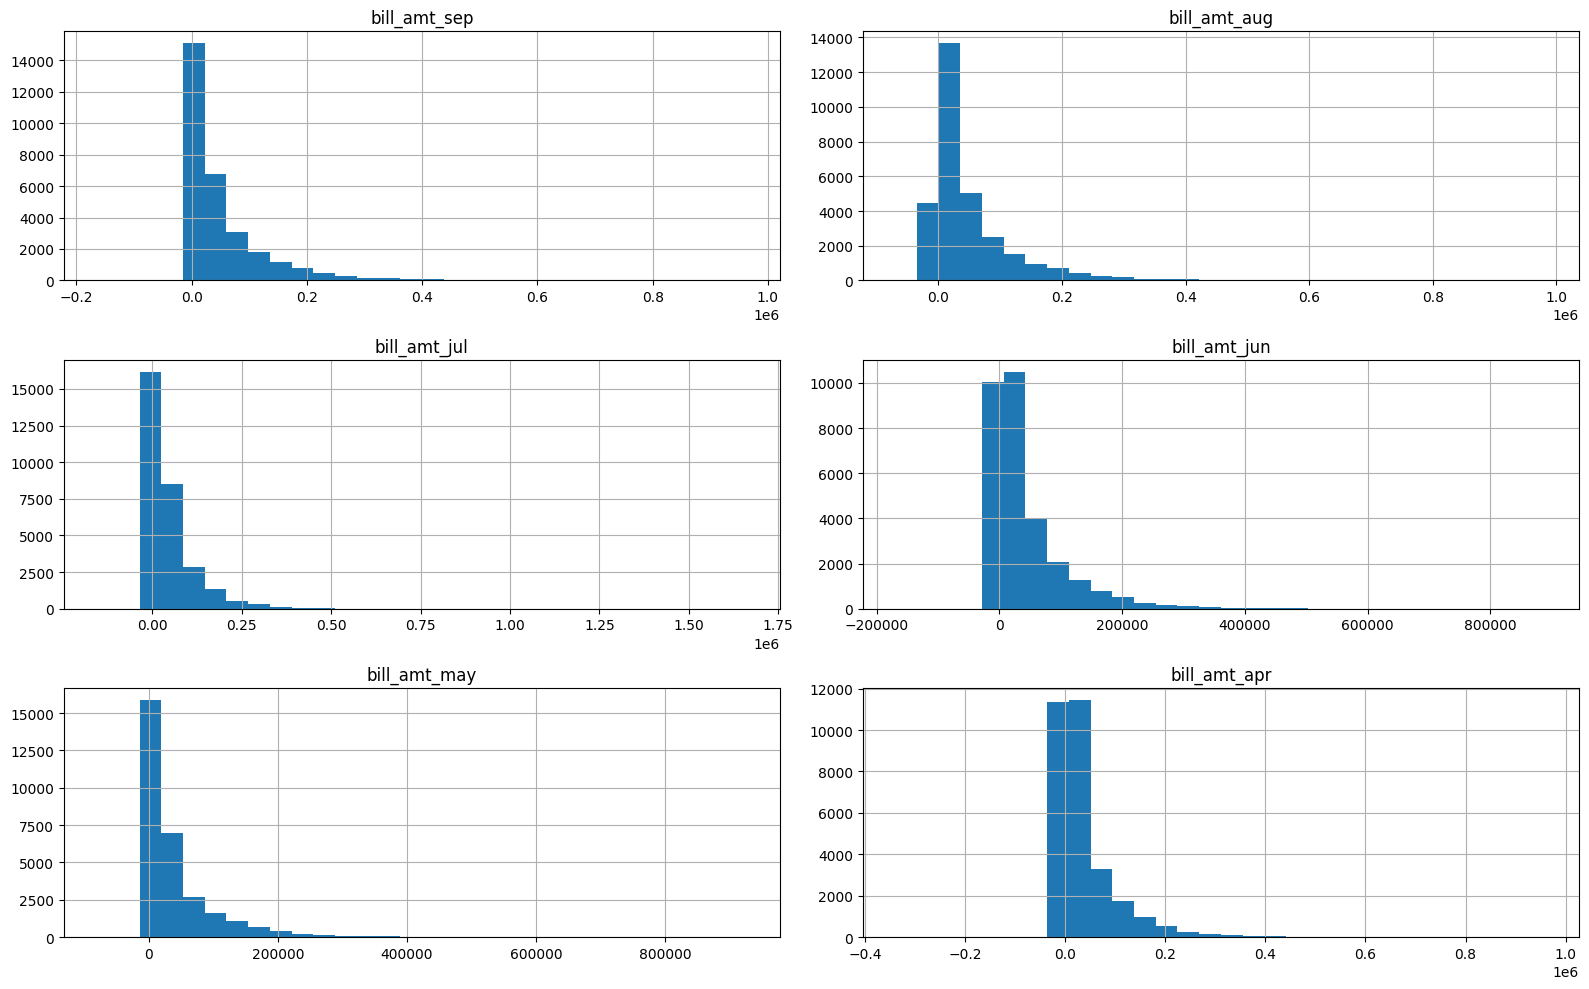

In [51]:
df[bill_cols].hist(bins=30, figsize=(16, 10))

plt.tight_layout()
plt.show()

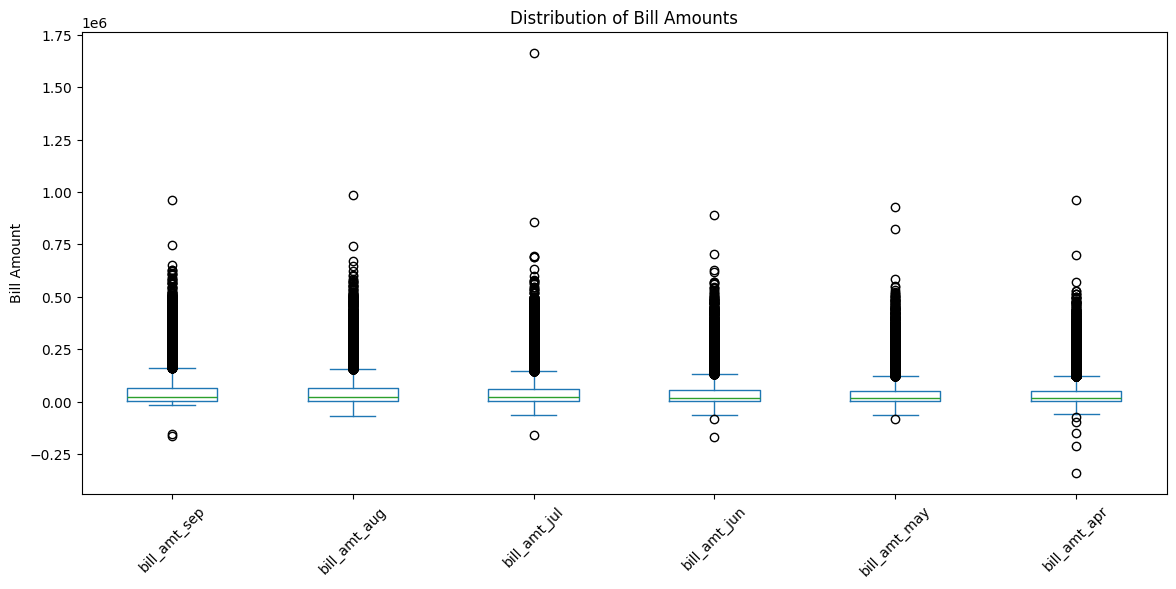

In [52]:
df[bill_cols].plot(kind='box', figsize=(14, 6))

plt.xticks(rotation=45)
plt.ylabel('Bill Amount')
plt.title('Distribution of Bill Amounts')
plt.show()

In [53]:
pay_cols = ['pay_amt_sep', 'pay_amt_aug', 'pay_amt_jul', 'pay_amt_jun', 'pay_amt_may', 'pay_amt_apr']

df[pay_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
pay_amt_sep,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0
pay_amt_aug,30000.0,5921.163500,23040.870402,0.0,833.00,2009.0,5000.00,1684259.0
pay_amt_jul,30000.0,5225.681500,17606.961470,0.0,390.00,1800.0,4505.00,896040.0
pay_amt_jun,30000.0,4826.076867,15666.159744,0.0,296.00,1500.0,4013.25,621000.0
pay_amt_may,30000.0,4799.387633,15278.305679,0.0,252.50,1500.0,4031.50,426529.0
pay_amt_apr,30000.0,5215.502567,17777.465775,0.0,117.75,1500.0,4000.00,528666.0


In [54]:
df[pay_cols].skew().sort_values(ascending=False)

,0
pay_amt_aug,30.453817
pay_amt_jul,17.216635
pay_amt_sep,14.668364
pay_amt_jun,12.904985
pay_amt_may,11.127417
pay_amt_apr,10.640727


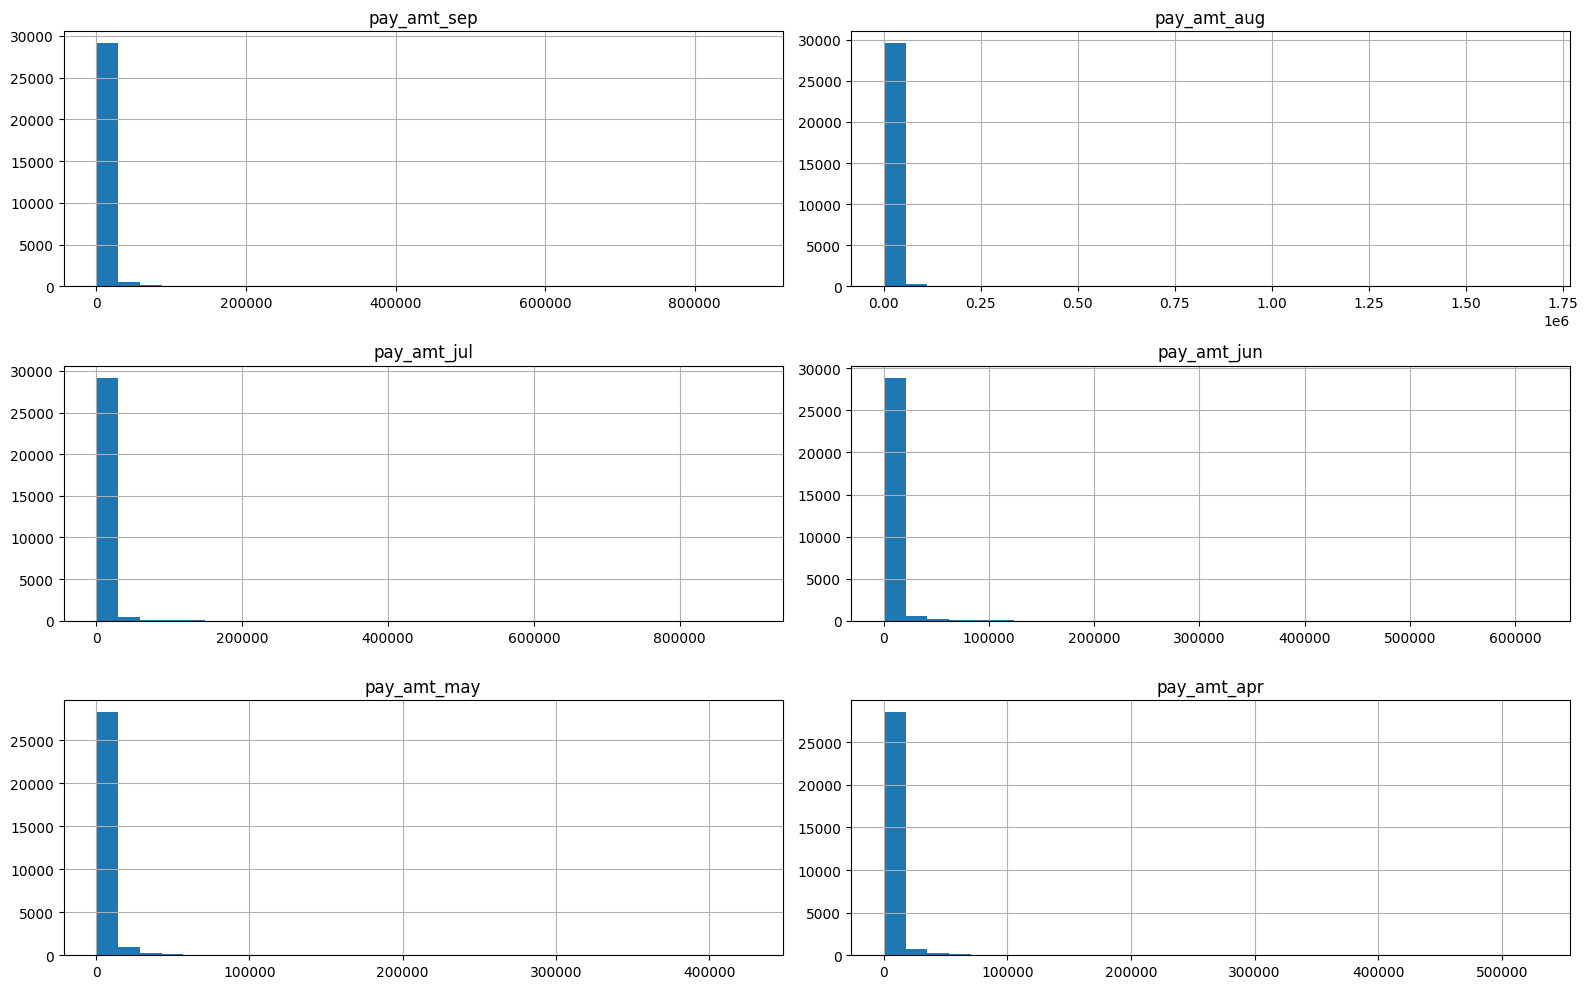

In [55]:
df[pay_cols].hist(bins=30, figsize=(16, 10))

plt.tight_layout()
plt.show()

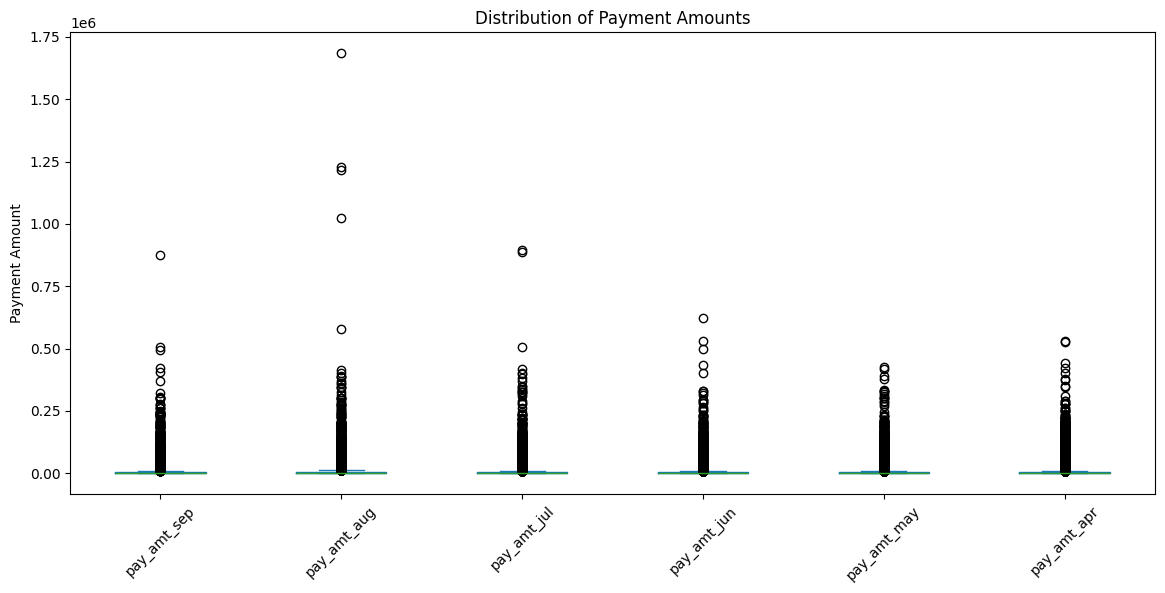

In [56]:
df[pay_cols].plot(kind='box', figsize=(14, 6))

plt.xticks(rotation=45)
plt.ylabel('Payment Amount')
plt.title('Distribution of Payment Amounts')
plt.show()

In [57]:
for col in categorical_cols:
  print(pd.crosstab(df['default_next_month'], df[col], normalize='index') * 100)
  print('\n')

sex                         1          2
default_next_month                      
0                   38.585003  61.414997
1                   43.294153  56.705847


education                  0          1          2          3         4  \
default_next_month                                                        
0                   0.059921  36.590481  45.796953  15.750728  0.496490   
1                   0.000000  30.681133  50.180832  18.640747  0.105485   

education                  5         6  
default_next_month                      
0                   1.121383  0.184044  
1                   0.271248  0.120555  


marital_status             0          1          2         3
default_next_month                                          
0                   0.209724  44.739771  54.027564  1.022941
1                   0.075347  48.312236  50.346594  1.265823




In [58]:
df.groupby('default_next_month')['credit_limit'].describe()

,count,mean,std,min,25%,50%,75%,max
default_next_month,,,,,,,,
0,23364.0,178099.726074,131628.359660,10000.0,70000.0,150000.0,250000.0,1000000.0
1,6636.0,130109.656420,115378.540571,10000.0,50000.0,90000.0,200000.0,740000.0


In [59]:
df.groupby('default_next_month')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
default_next_month,,,,,,,,
0,23364.0,35.417266,9.077355,21.0,28.0,34.0,41.0,79.0
1,6636.0,35.725738,9.693438,21.0,28.0,34.0,42.0,75.0


In [60]:
df.groupby('default_next_month')[bill_cols+pay_cols].describe()

bill_amt_sep                                        \
                          count          mean           std       min   
default_next_month                                                      
0                       23364.0  51994.227273  73577.606694 -165580.0   
1                        6636.0  48509.162297  73782.067220   -6676.0   

                                                        bill_amt_aug  \
                        25%      50%      75%       max        count   
default_next_month                                                     
0                   3677.25  23119.5  69027.0  964511.0      23364.0   
1                   2987.75  20185.0  59626.5  613860.0       6636.0   

                                  ... pay_amt_may           pay_amt_apr  \
                            mean  ...         75%       max       count   
default_next_month                ...                                     
0                   49717.435670  ...      4600.0  426529.0     23364.0   
1                   47283.617842  ...      3000.0  332000.0      6636.0   

                                                                           \
                           mean           std  min    25%     50%     75%   
default_next_month                                                          
0                   5719.371769  18792.950473  0.0  300.0  1706.0  4545.0   
1                   3441.482068  13464.005894  0.0    0.0  1000.0  2974.5   

                              
                         max  
default_next_month            
0                   528666.0  
1                   345293.0  

[2 rows x 96 columns]

In [61]:
df[['credit_limit']+bill_cols].corr()

,credit_limit,bill_amt_sep,bill_amt_aug,bill_amt_jul,bill_amt_jun,bill_amt_may,bill_amt_apr
credit_limit,1.000000,0.285430,0.278314,0.283236,0.293988,0.295562,0.290389
bill_amt_sep,0.285430,1.000000,0.951484,0.892279,0.860272,0.829779,0.802650
bill_amt_aug,0.278314,0.951484,1.000000,0.928326,0.892482,0.859778,0.831594
bill_amt_jul,0.283236,0.892279,0.928326,1.000000,0.923969,0.883910,0.853320
bill_amt_jun,0.293988,0.860272,0.892482,0.923969,1.000000,0.940134,0.900941
bill_amt_may,0.295562,0.829779,0.859778,0.883910,0.940134,1.000000,0.946197
bill_amt_apr,0.290389,0.802650,0.831594,0.853320,0.900941,0.946197,1.000000


In [62]:
df[pay_cols].corr()

,pay_amt_sep,pay_amt_aug,pay_amt_jul,pay_amt_jun,pay_amt_may,pay_amt_apr
pay_amt_sep,1.000000,0.285576,0.252191,0.199558,0.148459,0.185735
pay_amt_aug,0.285576,1.000000,0.244770,0.180107,0.180908,0.157634
pay_amt_jul,0.252191,0.244770,1.000000,0.216325,0.159214,0.162740
pay_amt_jun,0.199558,0.180107,0.216325,1.000000,0.151830,0.157834
pay_amt_may,0.148459,0.180908,0.159214,0.151830,1.000000,0.154896
pay_amt_apr,0.185735,0.157634,0.162740,0.157834,0.154896,1.000000


In [63]:
df[bill_cols+pay_cols].corr()

,bill_amt_sep,bill_amt_aug,bill_amt_jul,bill_amt_jun,bill_amt_may,bill_amt_apr,pay_amt_sep,pay_amt_aug,pay_amt_jul,pay_amt_jun,pay_amt_may,pay_amt_apr
bill_amt_sep,1.000000,0.951484,0.892279,0.860272,0.829779,0.802650,0.140277,0.099355,0.156887,0.158303,0.167026,0.179341
bill_amt_aug,0.951484,1.000000,0.928326,0.892482,0.859778,0.831594,0.280365,0.100851,0.150718,0.147398,0.157957,0.174256
bill_amt_jul,0.892279,0.928326,1.000000,0.923969,0.883910,0.853320,0.244335,0.316936,0.130011,0.143405,0.179712,0.182326
bill_amt_jun,0.860272,0.892482,0.923969,1.000000,0.940134,0.900941,0.233012,0.207564,0.300023,0.130191,0.160433,0.177637
bill_amt_may,0.829779,0.859778,0.883910,0.940134,1.000000,0.946197,0.217031,0.181246,0.252305,0.293118,0.141574,0.164184
bill_amt_apr,0.802650,0.831594,0.853320,0.900941,0.946197,1.000000,0.199965,0.172663,0.233770,0.250237,0.307729,0.115494
pay_amt_sep,0.140277,0.280365,0.244335,0.233012,0.217031,0.199965,1.000000,0.285576,0.252191,0.199558,0.148459,0.185735
pay_amt_aug,0.099355,0.100851,0.316936,0.207564,0.181246,0.172663,0.285576,1.000000,0.244770,0.180107,0.180908,0.157634
pay_amt_jul,0.156887,0.150718,0.130011,0.300023,0.252305,0.233770,0.252191,0.244770,1.000000,0.216325,0.159214,0.162740
pay_amt_jun,0.158303,0.147398,0.143405,0.130191,0.293118,0.250237,0.199558,0.180107,0.216325,1.000000,0.151830,0.157834


In [64]:
corr_matrix = df.corr(numeric_only=True)

<function matplotlib.pyplot.show(close=None, block=None)>

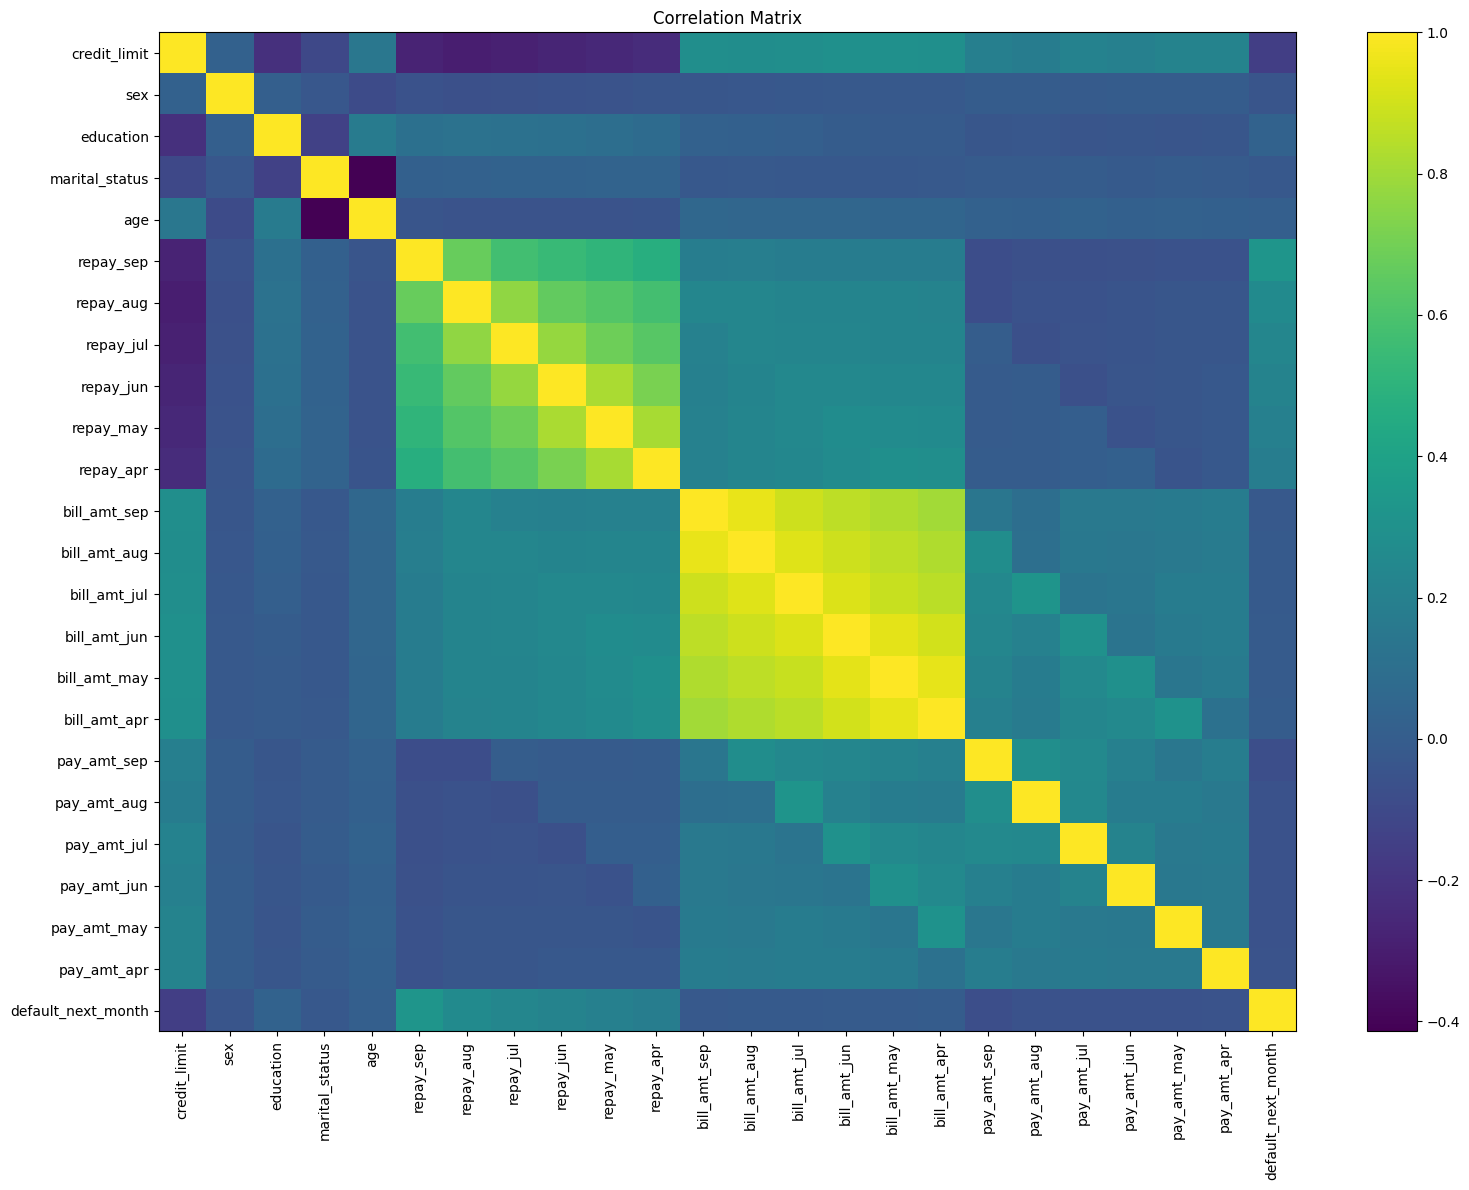

In [65]:
plt.figure(figsize=(16, 12))

plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show

In [66]:
corr_matrix['default_next_month'].sort_values()

,default_next_month
credit_limit,-0.153520
pay_amt_sep,-0.072929
pay_amt_aug,-0.058579
pay_amt_jun,-0.056827
pay_amt_jul,-0.056250
pay_amt_may,-0.055124
pay_amt_apr,-0.053183
sex,-0.039961
marital_status,-0.024339
bill_amt_sep,-0.019644


In [67]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [68]:
X_vif = df.drop(columns=['default_next_month'])

In [69]:
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data.sort_values(by='VIF', ascending=False)

,feature,VIF
12,bill_amt_aug,25.864853
15,bill_amt_may,24.996689
13,bill_amt_jul,21.775684
14,bill_amt_jun,20.346841
16,bill_amt_apr,15.024784
11,bill_amt_sep,14.032744
9,repay_may,4.725098
8,repay_jun,4.287408
7,repay_jul,3.657496
10,repay_apr,3.256188


### Key EDA Findings

- The target variable is imbalanced, with non-default customers
  representing the majority of observations.
- Several financial variables show substantial right-skewness.
- Repayment history contains coded values representing different
  repayment-status categories.
- Monthly billing variables exhibit strong relationships with one another.
- Monthly payment variables also show relationships across months.
- Multicollinearity was assessed using correlation analysis and VIF.
- These findings informed the preprocessing and feature-engineering
  decisions used in the predictive modeling stage.

## Milestone 4 — Data Preprocessing

### 4.1 Duplicate Records
- Recheck duplicate observations
- Remove exact duplicate records
- Verify the updated dataset size

### 4.2 Missing Values
- Check for missing values
- Confirm whether any missing-value treatment is required

### 4.3 Feature and Target Separation
- Define the predictor variables (`x`)
- Define the target variable (`y`)
- Verify dimensions of `x` and `y`

### 4.4 Feature Classification
- Identify numerical variables
- Identify categorical variables
- Identify repayment-history variables
- Confirm each variable's data type and role

### 4.5 Categorical Variable Encoding
- Review the coding of `sex`, `education`, and `marital_status`
- Determine appropriate encoding methods
- Encode categorical predictors for modeling

### 4.6 Repayment-Status Encoding
- Review repayment-status codes (`-2`, `-1`, `0`, `1–9`)
- Determine how the codes should be represented for modeling
- Create appropriate repayment-history features if required

### 4.7 Feature Scaling
- Identify variables requiring scaling
- Apply standardization to appropriate numerical predictors
- Ensure scaling is performed without data leakage

### 4.8 Train-Test Split
- Split the dataset into training and testing sets
- Use stratification to preserve the target-class distribution
- Set a random state for reproducibility

### 4.9 Preprocessing Pipeline
- Combine preprocessing steps into a reproducible pipeline
- Ensure transformations are fitted only on the training data
- Prepare the processed data for model development

### 4.10 Preprocessing Verification
- Verify the final feature dimensions
- Confirm there are no unintended missing values
- Confirm categorical variables have been encoded correctly
- Confirm numerical features have been scaled appropriately
- Verify target distribution in training and testing sets

### 4.11 Milestone 4 Findings
- Document duplicate-record treatment
- Document missing-value findings
- Document encoding decisions
- Document repayment-status treatment
- Document scaling approach
- Document train-test split and class stratification
- Confirm that the dataset is ready for predictive modeling

In [70]:
df.duplicated().sum()

np.int64(35)

In [71]:
df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

,credit_limit,sex,education,marital_status,age,repay_sep,repay_aug,repay_jul,repay_jun,repay_may,...,bill_amt_jun,bill_amt_may,bill_amt_apr,pay_amt_sep,pay_amt_aug,pay_amt_jul,pay_amt_jun,pay_amt_may,pay_amt_apr,default_next_month
12430,20000,1,2,2,24,2,2,4,4,4,...,1650,1650,1650,0,0,0,0,0,0,1
14294,20000,1,2,2,24,2,2,4,4,4,...,1650,1650,1650,0,0,0,0,0,0,1
1759,50000,1,2,2,26,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
10250,50000,1,2,2,26,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
7170,50000,2,1,2,23,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27966,360000,2,1,2,27,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
18325,360000,2,1,2,29,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
22162,360000,2,1,2,29,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
839,500000,1,1,1,43,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,1


In [72]:
df = df.drop_duplicates().copy()

print("Dataset shape after removing duplicates:", df.shape)
print("Remaining duplicate rows:", df.duplicated().sum())

Dataset shape after removing duplicates: (29965, 24)
Remaining duplicate rows: 0


In [73]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

,0
credit_limit,0
sex,0
education,0
marital_status,0
age,0
repay_sep,0
repay_aug,0
repay_jul,0
repay_jun,0
repay_may,0


In [74]:
print("Total missing values: ", df.isnull().sum().sum())

Total missing values:  0


In [75]:
missing_percentage = (df.isnull().sum() / df.shape[0]).sort_values(ascending=False)
missing_percentage

,0
credit_limit,0.0
sex,0.0
education,0.0
marital_status,0.0
age,0.0
repay_sep,0.0
repay_aug,0.0
repay_jul,0.0
repay_jun,0.0
repay_may,0.0


In [76]:
if df.isnull().sum().sum() == 0:
    print("No missing values found in the dataset.")
else:
    print("Missing values require further investigation.")

No missing values found in the dataset.


In [77]:
x = df.drop(columns=['default_next_month'])
y = df[['default_next_month']]

print("Feature matrix shape:", x.shape)
print("Target shape:", y.shape)

Feature matrix shape: (29965, 23)
Target shape: (29965, 1)


In [78]:
print(y.value_counts())

default_next_month
0                     23335
1                      6630
Name: count, dtype: int64


In [79]:
print(x.columns.tolist())

['credit_limit', 'sex', 'education', 'marital_status', 'age', 'repay_sep', 'repay_aug', 'repay_jul', 'repay_jun', 'repay_may', 'repay_apr', 'bill_amt_sep', 'bill_amt_aug', 'bill_amt_jul', 'bill_amt_jun', 'bill_amt_may', 'bill_amt_apr', 'pay_amt_sep', 'pay_amt_aug', 'pay_amt_jul', 'pay_amt_jun', 'pay_amt_may', 'pay_amt_apr']


In [80]:
categorical_cols

['sex', 'education', 'marital_status']

In [81]:
repay_cols

['repay_sep', 'repay_aug', 'repay_jul', 'repay_jun', 'repay_may', 'repay_apr']

In [82]:
numerical_cols = ['credit_limit', 'age'] + bill_cols + pay_cols

numerical_cols

['credit_limit',
 'age',
 'bill_amt_sep',
 'bill_amt_aug',
 'bill_amt_jul',
 'bill_amt_jun',
 'bill_amt_may',
 'bill_amt_apr',
 'pay_amt_sep',
 'pay_amt_aug',
 'pay_amt_jul',
 'pay_amt_jun',
 'pay_amt_may',
 'pay_amt_apr']

In [83]:
classified_cols = categorical_cols + repay_cols + numerical_cols

print("Number of features:", len(x.columns))
print("Number classified: ", len(classified_cols))

Number of features: 23
Number classified:  23


In [84]:
unclassified_cols = [col for col in x.columns if col not in classified_cols]

print("Unclassified features:", unclassified_cols)

Unclassified features: []


In [85]:
from collections import Counter

column_counts = Counter(classified_cols)

duplicate_classifications = {col: count for col,
                             count in column_counts.items() if count > 1}

print("Features appearing in multiple groups:"), duplicate_classifications

Features appearing in multiple groups:


(None, {})

In [86]:
for col in categorical_cols:
    print(df[col].value_counts().sort_index())
    print('\n')

sex
1    11874
2    18091
Name: count, dtype: int64


education
0       14
1    10563
2    14019
3     4915
4      123
5      280
6       51
Name: count, dtype: int64


marital_status
0       54
1    13643
2    15945
3      323
Name: count, dtype: int64




In [87]:
df[categorical_cols].dtypes

,0
sex,int64
education,int64
marital_status,int64


In [88]:
for col in categorical_cols:
  print(f"{col}:")
  print(sorted(df[col].unique()))
  print()

sex:
[np.int64(1), np.int64(2)]

education:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

marital_status:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]



In [89]:
x[categorical_cols] = x[categorical_cols].astype(str)

x[categorical_cols].dtypes

,0
sex,object
education,object
marital_status,object


In [90]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [91]:
categorical_encoder = OneHotEncoder(handle_unknown='ignore', drop="first")

In [92]:
for col in repay_cols:
  print(df[col].value_counts().sort_index())
  print()

repay_sep
-2     2750
-1     5682
 0    14737
 1     3667
 2     2666
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

repay_aug
-2     3752
-1     6046
 0    15730
 1       28
 2     3926
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

repay_jul
-2     4055
-1     5934
 0    15764
 1        4
 2     3819
 3      240
 4       75
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

repay_jun
-2     4318
-1     5683
 0    16455
 1        2
 2     3159
 3      180
 4       68
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

repay_may
-2     4516
-1     5535
 0    16947
 2     2626
 3      178
 4       83
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

repay_apr
-2     4865
-1     5736
 0    16286
 2     2766
 3      184
 4       48
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int64



In [93]:
repay_codes = sorted(set(df[repay_cols].values.flatten()))

print("Repayment codes:", repay_codes)

Repayment codes: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [94]:
repay_code_counts = (df[repay_cols].stack().value_counts().sort_index())

repay_code_counts

,count
-2,24256
-1,34616
0,95919
1,3701
2,18962
3,1430
4,449
5,137
6,74
7,218


In [95]:
repay_code_percentages = repay_code_counts/ repay_code_counts.sum() * 100

repay_code_percentages

,count
-2,13.491295
-1,19.253574
0,53.350576
1,2.058513
2,10.546749
3,0.795372
4,0.249736
5,0.076200
6,0.041159
7,0.121253


In [96]:
for col in repay_cols:
  print(pd.crosstab(df['default_next_month'], df[col], normalize='index') * 100)
  print()

repay_sep                  -2        -1          0          1          2  \
default_next_month                                                         
0                   10.224984  20.26141  55.063210  10.366402   3.526891   
1                    5.490196  14.38914  28.476621  18.823529  27.797888   

repay_sep                  3         4         5         6         7         8  
default_next_month                                                              
0                   0.334262  0.102850  0.055710  0.021427  0.008571  0.034283  
1                   3.680241  0.784314  0.196078  0.090498  0.105581  0.165913  

repay_aug                  -2         -1          0         1          2  \
default_next_month                                                         
0                   13.139061  21.769874  56.683094  0.098564   7.469466   
1                   10.346908  14.570136  37.752640  0.075415  32.926094   

repay_aug                  3         4         5         6       

In [97]:
for col in repay_cols:
  print(col, "min = ", df[col].min(), "max = ", df[col].max())

repay_sep min =  -2 max =  8
repay_aug min =  -2 max =  8
repay_jul min =  -2 max =  8
repay_jun min =  -2 max =  8
repay_may min =  -2 max =  8
repay_apr min =  -2 max =  8


In [98]:
x_repay = x[repay_cols].copy()

In [99]:
for col in repay_cols:
  print(f"\n{col}:")
  print(sorted(x_repay[col].unique()))



repay_sep:
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

repay_aug:
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

repay_jul:
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

repay_jun:
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

repay_may:
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

repay_apr:
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [100]:
from sklearn.preprocessing import StandardScaler

In [101]:
scaler = StandardScaler()

In [102]:
from sklearn.model_selection import train_test_split

In [103]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [104]:
print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (23972, 23)
x_test: (5993, 23)
y_train: (23972, 1)
y_test: (5993, 1)


In [105]:
print(y_train.value_counts(normalize=True) * 100)

default_next_month
0                     77.874187
1                     22.125813
Name: proportion, dtype: float64


In [106]:
print(y_test.value_counts(normalize=True) * 100)

default_next_month
0                     77.874187
1                     22.125813
Name: proportion, dtype: float64


In [107]:
from sklearn.pipeline import Pipeline

numerical_pipeline = Pipeline([('scalar', StandardScaler())])
categorical_pipeline = Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore',
                                  drop='first', sparse_output=False))])

In [108]:
preprocessor = ColumnTransformer([('numerical', numerical_pipeline, numerical_cols),
                                  ('categorical', categorical_pipeline,
                                   categorical_cols)], remainder='passthrough')

In [109]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [110]:
print("Original training shape:", x_train.shape)
print("Original testing shape:", x_test.shape)

print("Processed training shape:", x_train_processed.shape)
print("Processed testing shape:", x_test_processed.shape)

Original training shape: (23972, 23)
Original testing shape: (5993, 23)
Processed training shape: (23972, 30)
Processed testing shape: (5993, 30)


In [111]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print(feature_names)

Number of processed features: 30
['numerical__credit_limit' 'numerical__age' 'numerical__bill_amt_sep'
 'numerical__bill_amt_aug' 'numerical__bill_amt_jul'
 'numerical__bill_amt_jun' 'numerical__bill_amt_may'
 'numerical__bill_amt_apr' 'numerical__pay_amt_sep'
 'numerical__pay_amt_aug' 'numerical__pay_amt_jul'
 'numerical__pay_amt_jun' 'numerical__pay_amt_may'
 'numerical__pay_amt_apr' 'categorical__sex_2' 'categorical__education_1'
 'categorical__education_2' 'categorical__education_3'
 'categorical__education_4' 'categorical__education_5'
 'categorical__education_6' 'categorical__marital_status_1'
 'categorical__marital_status_2' 'categorical__marital_status_3'
 'remainder__repay_sep' 'remainder__repay_aug' 'remainder__repay_jul'
 'remainder__repay_jun' 'remainder__repay_may' 'remainder__repay_apr']


In [112]:
x_train_processed_df = pd.DataFrame(x_train_processed, columns=feature_names,
                                    index = x_train.index)
x_train_processed_df.head()

,numerical__credit_limit,numerical__age,numerical__bill_amt_sep,numerical__bill_amt_aug,numerical__bill_amt_jul,numerical__bill_amt_jun,numerical__bill_amt_may,numerical__bill_amt_apr,numerical__pay_amt_sep,numerical__pay_amt_aug,...,categorical__education_6,categorical__marital_status_1,categorical__marital_status_2,categorical__marital_status_3,remainder__repay_sep,remainder__repay_aug,remainder__repay_jul,remainder__repay_jun,remainder__repay_may,remainder__repay_apr
27420,1.022024,-0.050264,-0.700030,-0.694464,-0.678531,-0.674057,-0.665085,-0.652938,-0.338846,-0.245685,...,0.0,1.0,0.0,0.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0
15350,-0.903020,0.167213,-0.049079,-0.005582,0.032115,0.072324,-0.220084,-0.208968,-0.200960,-0.183578,...,0.0,0.0,0.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0
26641,-0.672015,-1.355126,-0.693968,-0.688208,-0.672134,-0.660258,-0.650460,-0.645486,-0.312228,-0.227301,...,0.0,0.0,1.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0
21618,-0.903020,-1.028910,-0.694705,-0.665187,-0.672912,-0.667997,-0.665085,-0.639846,-0.214269,-0.229537,...,0.0,0.0,1.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
11570,0.252006,-0.593956,-0.037938,0.009043,-0.321904,1.244053,1.513376,1.516122,0.877787,0.784923,...,0.0,0.0,1.0,0.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0


In [113]:
x_test_processed_df = pd.DataFrame(x_test_processed, columns=feature_names,
                                   index = x_test.index)
x_test_processed_df.head()

,numerical__credit_limit,numerical__age,numerical__bill_amt_sep,numerical__bill_amt_aug,numerical__bill_amt_jul,numerical__bill_amt_jun,numerical__bill_amt_may,numerical__bill_amt_apr,numerical__pay_amt_sep,numerical__pay_amt_aug,...,categorical__education_6,categorical__marital_status_1,categorical__marital_status_2,categorical__marital_status_3,remainder__repay_sep,remainder__repay_aug,remainder__repay_jul,remainder__repay_jun,remainder__repay_may,remainder__repay_apr
8687,-0.903020,0.819644,-0.165121,-0.136452,-0.432596,-0.471461,-0.518437,-0.573376,-0.218945,-0.183578,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24201,0.560013,-0.485218,1.598916,1.740194,1.857348,2.110130,2.312826,2.441981,0.119655,0.081413,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27782,-0.595013,-1.137649,-0.616880,-0.589122,-0.551054,-0.516570,-0.471876,-0.516340,-0.248920,-0.183578,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14947,-0.903020,-1.463864,-0.281805,-0.265054,-0.270787,-0.257163,-0.217548,-0.209404,-0.050544,-0.245685,...,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
1486,0.483012,-0.376479,-0.089248,-0.029786,-0.252331,-0.076958,0.034887,0.077742,0.267852,0.582412,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [114]:
print("Missing values in processed training data:", x_train_processed_df.isnull().sum().sum())
print("Missing values in processed testing data:", x_test_processed_df.isnull().sum().sum())

Missing values in processed training data: 0
Missing values in processed testing data: 0


In [115]:
print("Same number of features:",
      x_train_processed_df.shape[1] == x_test_processed_df.shape[1])

Same number of features: True


In [116]:
scaled_columns = [col for col in x_train_processed_df.columns
                  if col.startswith('numerical')]

x_train_processed_df[scaled_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
numerical__credit_limit,23972.0,3.793988e-17,1.000021,-1.211027,-0.903020,-0.210004,0.560013,6.412147
numerical__age,23972.0,-7.350851e-17,1.000021,-1.572603,-0.811433,-0.159003,0.602167,4.299274
numerical__bill_amt_sep,23972.0,1.719151e-17,1.000021,-2.960801,-0.651150,-0.391635,0.224649,12.469063
numerical__bill_amt_aug,23972.0,-1.896994e-17,1.000021,-1.677532,-0.652102,-0.390922,0.211219,13.167867
numerical__bill_amt_jul,23972.0,2.371242e-17,1.000021,-2.944300,-0.638853,-0.386543,0.191112,23.296700
numerical__bill_amt_jun,23972.0,2.015556e-17,1.000021,-1.937900,-0.636764,-0.375803,0.176159,13.180232
numerical__bill_amt_may,23972.0,-1.304183e-17,1.000021,-1.675877,-0.635740,-0.365011,0.167042,14.605355
numerical__bill_amt_apr,23972.0,-2.060017e-17,1.000021,-6.353269,-0.632078,-0.365323,0.173976,15.488858
numerical__pay_amt_sep,23972.0,1.837713e-17,1.000021,-0.338846,-0.278895,-0.212950,-0.038554,52.030927
numerical__pay_amt_aug,23972.0,-1.274543e-17,1.000021,-0.245685,-0.210408,-0.162461,-0.038661,69.490788


In [117]:
print("Final original dataset shapes:", df.shape)
print("Training observations:", x_train.shape[0])
print("Testing observations:", x_test.shape[0])
print("Processed training features:", x_train_processed_df.shape[1])
print("Processed testing features:", x_test_processed_df.shape[1])

Final original dataset shapes: (29965, 24)
Training observations: 23972
Testing observations: 5993
Processed training features: 30
Processed testing features: 30


In [118]:
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())
print("Processed training missing values:", x_train_processed_df.isnull().sum().sum())
print("Processed testing missing values:", x_test_processed_df.isnull().sum().sum())

Duplicate rows: 0
Missing values: 0
Processed training missing values: 0
Processed testing missing values: 0


### Milestone 4 Summary

The dataset was prepared for predictive modeling through a structured preprocessing workflow.

Duplicate records were identified and removed, and the dataset was checked for missing values. The predictor variables were separated from the binary target variable, `default_next_month`.

Features were classified into numerical, categorical, and repayment-history variables. Categorical variables were prepared for one-hot encoding, while repayment-history variables were examined separately because their coded values represent repayment status rather than ordinary continuous measurements.

The data was divided into training and testing sets using stratified sampling to preserve the target-class distribution. Numerical features were standardized using `StandardScaler`, while categorical features were encoded using `OneHotEncoder`.

All preprocessing transformations were fitted only on the training data and then applied to the testing data to prevent data leakage.

The final preprocessing pipeline produced consistent training and testing feature sets with no unintended missing values. The processed data is now ready for multicollinearity assessment and predictive model development.

## Milestone 5 — Multicollinearity & Feature Selection

### 5.1 Feature Correlation Analysis
- Calculate correlations among numerical features
- Identify strongly correlated predictors
- Examine relationships among credit limit, billing, and payment variables

### 5.2 Correlation with Target
- Calculate correlations between numerical predictors and `default_next_month`
- Identify features with stronger relationships with the target
- Distinguish correlation from predictive importance

### 5.3 Correlation Heatmap
- Create a correlation matrix
- Visualize relationships using a heatmap
- Identify clusters of highly correlated predictors

### 5.4 Multicollinearity Assessment
- Calculate Variance Inflation Factor (VIF)
- Identify predictors with high VIF values
- Investigate potential multicollinearity among predictors

### 5.5 VIF Interpretation
- Establish practical VIF thresholds
- Identify variables requiring further investigation
- Determine whether highly correlated variables should be retained, transformed, combined, or removed

### 5.6 Feature Redundancy Analysis
- Examine highly correlated billing variables
- Examine highly correlated payment variables
- Examine relationships between credit limit and billing variables
- Determine whether redundant information exists

### 5.7 Feature Selection Decisions
- Review correlation and VIF findings together
- Decide which variables should remain in the modeling dataset
- Document the statistical reasoning behind feature-selection decisions

### 5.8 Final Feature Set
- Create the final predictor set
- Verify the number of predictors
- Confirm the target variable is excluded from the predictors
- Prepare the final feature set for model development

### 5.9 Milestone 5 Findings
- Summarize major correlation findings
- Summarize VIF results
- Identify important multicollinearity concerns
- Document feature-selection decisions
- Confirm the final dataset is ready for classification modeling

In [119]:
numerical_cols

['credit_limit',
 'age',
 'bill_amt_sep',
 'bill_amt_aug',
 'bill_amt_jul',
 'bill_amt_jun',
 'bill_amt_may',
 'bill_amt_apr',
 'pay_amt_sep',
 'pay_amt_aug',
 'pay_amt_jul',
 'pay_amt_jun',
 'pay_amt_may',
 'pay_amt_apr']

In [120]:
correlation_matrix = df[numerical_cols].corr()

correlation_matrix

,credit_limit,age,bill_amt_sep,bill_amt_aug,bill_amt_jul,bill_amt_jun,bill_amt_may,bill_amt_apr,pay_amt_sep,pay_amt_aug,pay_amt_jul,pay_amt_jun,pay_amt_may,pay_amt_apr
credit_limit,1.000000,0.144643,0.285877,0.278753,0.283671,0.294428,0.295999,0.290816,0.195454,0.178584,0.210375,0.203451,0.217421,0.219807
age,0.144643,1.000000,0.056092,0.054136,0.053566,0.051209,0.049202,0.047470,0.026068,0.021726,0.029181,0.021306,0.022777,0.019409
bill_amt_sep,0.285877,0.056092,1.000000,0.951457,0.892220,0.860196,0.829688,0.802547,0.140053,0.099181,0.156702,0.158110,0.166832,0.179166
bill_amt_aug,0.278753,0.054136,0.951457,1.000000,0.928287,0.892424,0.859704,0.831506,0.280190,0.100679,0.150532,0.147203,0.157761,0.174080
bill_amt_jul,0.283671,0.053566,0.892220,0.928287,1.000000,0.923929,0.883849,0.853245,0.244150,0.316832,0.129822,0.143211,0.179526,0.182155
bill_amt_jun,0.294428,0.051209,0.860196,0.892424,0.923929,1.000000,0.940103,0.900891,0.232824,0.207427,0.299887,0.129995,0.160242,0.177466
bill_amt_may,0.295999,0.049202,0.829688,0.859704,0.883849,0.940103,1.000000,0.946170,0.216840,0.181104,0.252156,0.292975,0.141380,0.164011
bill_amt_apr,0.290816,0.047470,0.802547,0.831506,0.853245,0.900891,0.946170,1.000000,0.199772,0.172519,0.233617,0.250082,0.307587,0.115309
pay_amt_sep,0.195454,0.026068,0.140053,0.280190,0.244150,0.232824,0.216840,0.199772,1.000000,0.285505,0.252105,0.199462,0.148356,0.185643
pay_amt_aug,0.178584,0.021726,0.099181,0.100679,0.316832,0.207427,0.181104,0.172519,0.285505,1.000000,0.244705,0.180033,0.180833,0.157562


In [121]:
correlation_pairs = (correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape),
                                                      k=1).astype(np.bool_)).stack()
                                                      .sort_values(ascending=False))

correlation_pairs

bill_amt_sep  bill_amt_aug    0.951457
bill_amt_may  bill_amt_apr    0.946170
bill_amt_jun  bill_amt_may    0.940103
bill_amt_aug  bill_amt_jul    0.928287
bill_amt_jul  bill_amt_jun    0.923929
                                ...   
age           pay_amt_sep     0.026068
              pay_amt_may     0.022777
              pay_amt_aug     0.021726
              pay_amt_jun     0.021306
              pay_amt_apr     0.019409
Length: 91, dtype: float64

In [122]:
strong_correlations = correlation_pairs[abs(correlation_pairs) >= 0.7]

strong_correlations

,,0
bill_amt_sep,bill_amt_aug,0.951457
bill_amt_may,bill_amt_apr,0.946170
bill_amt_jun,bill_amt_may,0.940103
bill_amt_aug,bill_amt_jul,0.928287
bill_amt_jul,bill_amt_jun,0.923929
bill_amt_jun,bill_amt_apr,0.900891
bill_amt_aug,bill_amt_jun,0.892424
bill_amt_sep,bill_amt_jul,0.892220
bill_amt_jul,bill_amt_may,0.883849
bill_amt_sep,bill_amt_jun,0.860196


In [123]:
strong_correlations_abs = (correlation_pairs.loc[correlation_pairs.abs() >= 0.70]
                           .sort_values(key=lambda x: x.abs(), ascending = False))

strong_correlations_abs

,,0
bill_amt_sep,bill_amt_aug,0.951457
bill_amt_may,bill_amt_apr,0.946170
bill_amt_jun,bill_amt_may,0.940103
bill_amt_aug,bill_amt_jul,0.928287
bill_amt_jul,bill_amt_jun,0.923929
bill_amt_jun,bill_amt_apr,0.900891
bill_amt_aug,bill_amt_jun,0.892424
bill_amt_sep,bill_amt_jul,0.892220
bill_amt_jul,bill_amt_may,0.883849
bill_amt_sep,bill_amt_jun,0.860196


In [124]:
target_correlation = (df[numerical_cols+['default_next_month']].corr()
['default_next_month'].drop('default_next_month').sort_values())

target_correlation

,default_next_month
credit_limit,-0.153871
pay_amt_sep,-0.073015
pay_amt_aug,-0.058643
pay_amt_jun,-0.056898
pay_amt_jul,-0.056319
pay_amt_may,-0.055194
pay_amt_apr,-0.053250
bill_amt_sep,-0.019758
bill_amt_aug,-0.014302
bill_amt_jul,-0.014182


In [125]:
target_correlation_abs = (target_correlation.sort_values(key=lambda x: x.abs(), ascending = False))

target_correlation_abs

,default_next_month
credit_limit,-0.153871
pay_amt_sep,-0.073015
pay_amt_aug,-0.058643
pay_amt_jun,-0.056898
pay_amt_jul,-0.056319
pay_amt_may,-0.055194
pay_amt_apr,-0.053250
bill_amt_sep,-0.019758
bill_amt_aug,-0.014302
bill_amt_jul,-0.014182


In [126]:
target_correlation_abs[target_correlation_abs >= 0.1]

,default_next_month


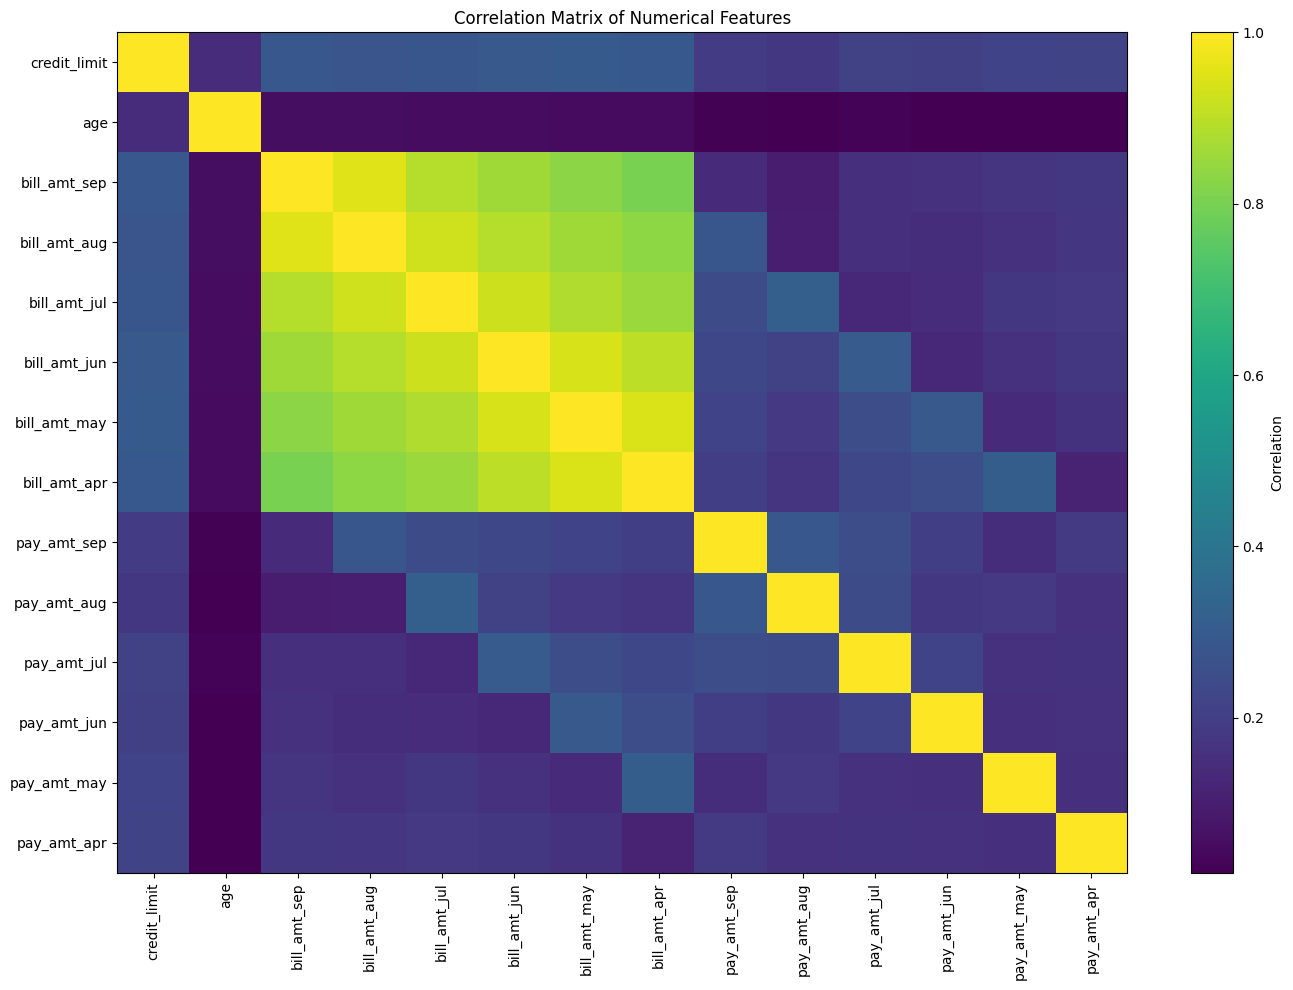

In [127]:
plt.figure(figsize=(14, 10))

plt.imshow(correlation_matrix, aspect='auto')

plt.colorbar(label='Correlation')

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns,
           rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

plt.title('Correlation Matrix of Numerical Features')

plt.tight_layout()
plt.show()


In [128]:
correlation_with_target = df[numerical_cols+['default_next_month']].corr()

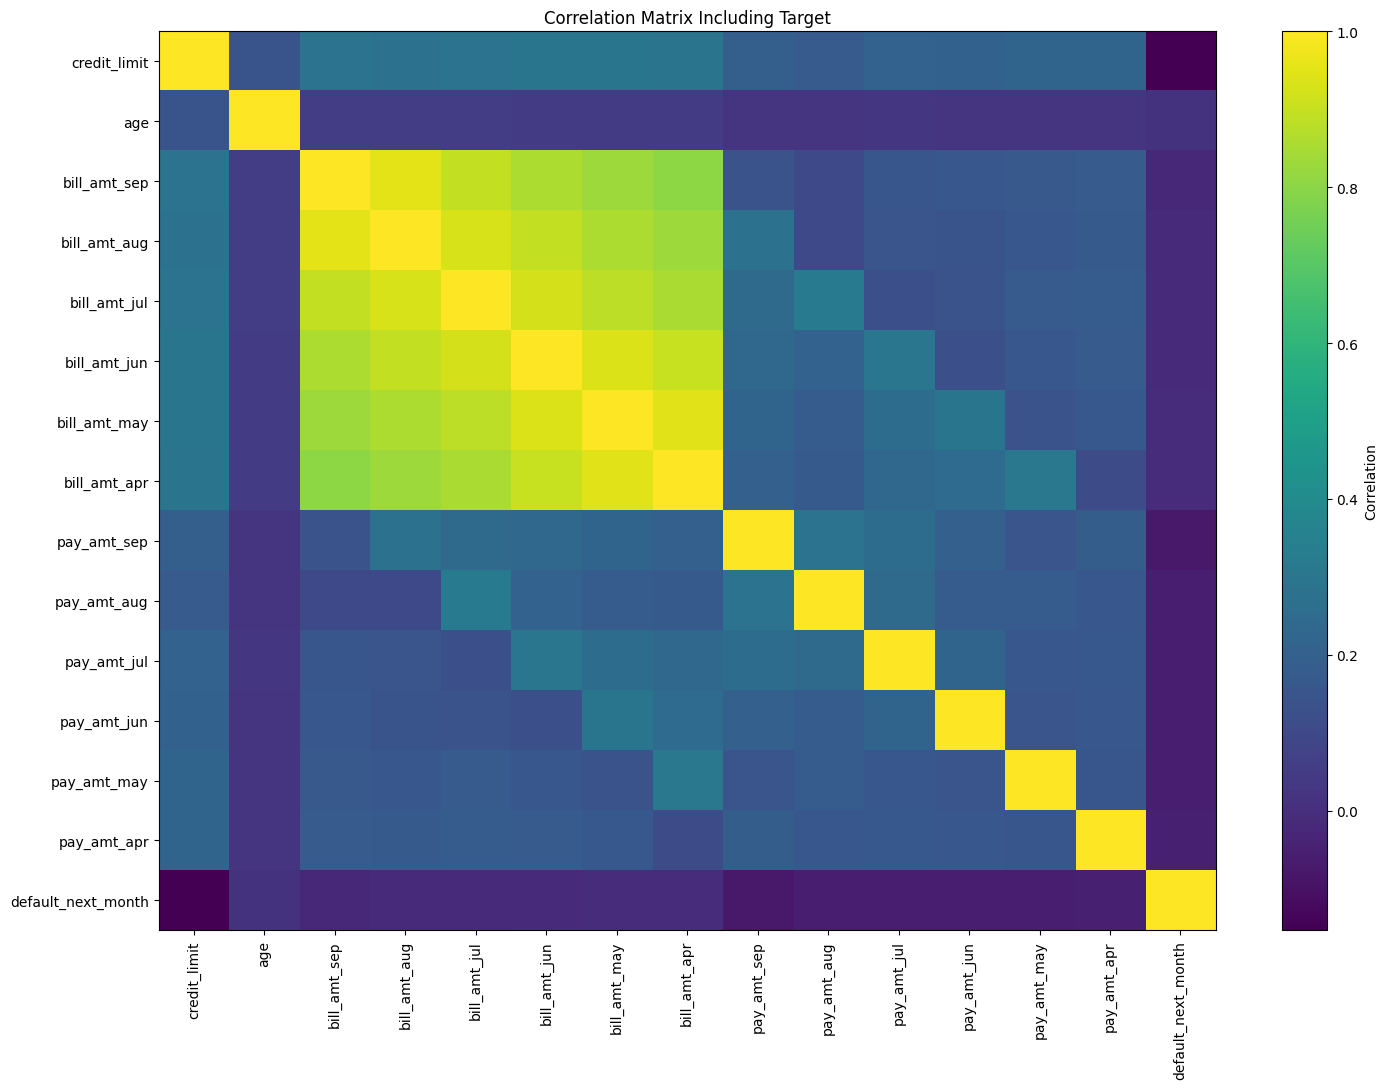

In [129]:
plt.figure(figsize=(15,11))

plt.imshow(correlation_with_target, aspect='auto')

plt.colorbar(label='Correlation')

plt.xticks(range(len(correlation_with_target.columns)), correlation_with_target.columns,
           rotation=90)
plt.yticks(range(len(correlation_with_target.columns)), correlation_with_target.columns)

plt.title('Correlation Matrix Including Target')

plt.tight_layout()
plt.show()

In [130]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [131]:
vif_data = df[numerical_cols].copy()

In [132]:
vif_results = pd.DataFrame()
vif_results['feature'] = vif_data.columns
vif_results['VIF'] = [variance_inflation_factor(vif_data.values, i)
for i in range(vif_data.shape[1])]

vif_results.sort_values(by='VIF', ascending=False)

,feature,VIF
3,bill_amt_aug,25.745863
6,bill_amt_may,24.873422
4,bill_amt_jul,21.715860
5,bill_amt_jun,20.236664
7,bill_amt_apr,14.919829
2,bill_amt_sep,13.907125
9,pay_amt_aug,2.222616
10,pay_amt_jul,1.734894
8,pay_amt_sep,1.691239
12,pay_amt_may,1.678741


In [133]:
vif_results['VIF'] = vif_results['VIF'].round(2)

vif_results.sort_values(by='VIF', ascending=False)

,feature,VIF
3,bill_amt_aug,25.75
6,bill_amt_may,24.87
4,bill_amt_jul,21.72
5,bill_amt_jun,20.24
7,bill_amt_apr,14.92
2,bill_amt_sep,13.91
9,pay_amt_aug,2.22
10,pay_amt_jul,1.73
8,pay_amt_sep,1.69
12,pay_amt_may,1.68


In [134]:
def interpret_vif(vif):
  if vif < 5:
    return 'Low multicollinearity'
  elif vif < 10:
    return 'Moderate multicollinearity'
  else:
    return 'High multicollinearity'

In [135]:
vif_results['Interpretation'] = vif_results['VIF'].apply(interpret_vif)

vif_results.sort_values(by='VIF', ascending=False)

,feature,VIF,Interpretation
3,bill_amt_aug,25.75,High multicollinearity
6,bill_amt_may,24.87,High multicollinearity
4,bill_amt_jul,21.72,High multicollinearity
5,bill_amt_jun,20.24,High multicollinearity
7,bill_amt_apr,14.92,High multicollinearity
2,bill_amt_sep,13.91,High multicollinearity
9,pay_amt_aug,2.22,Low multicollinearity
10,pay_amt_jul,1.73,Low multicollinearity
8,pay_amt_sep,1.69,Low multicollinearity
12,pay_amt_may,1.68,Low multicollinearity


In [136]:
high_vif = vif_results[vif_results['VIF'] >= 5].sort_values(by='VIF', ascending=False)

high_vif

,feature,VIF,Interpretation
3,bill_amt_aug,25.75,High multicollinearity
6,bill_amt_may,24.87,High multicollinearity
4,bill_amt_jul,21.72,High multicollinearity
5,bill_amt_jun,20.24,High multicollinearity
7,bill_amt_apr,14.92,High multicollinearity
2,bill_amt_sep,13.91,High multicollinearity


In [137]:
very_high_vif = vif_results[vif_results['VIF'] >= 10].sort_values(by='VIF', ascending=False)

very_high_vif

,feature,VIF,Interpretation
3,bill_amt_aug,25.75,High multicollinearity
6,bill_amt_may,24.87,High multicollinearity
4,bill_amt_jul,21.72,High multicollinearity
5,bill_amt_jun,20.24,High multicollinearity
7,bill_amt_apr,14.92,High multicollinearity
2,bill_amt_sep,13.91,High multicollinearity


In [138]:
bill_corr = df[bill_cols].corr()

bill_corr

,bill_amt_sep,bill_amt_aug,bill_amt_jul,bill_amt_jun,bill_amt_may,bill_amt_apr
bill_amt_sep,1.000000,0.951457,0.892220,0.860196,0.829688,0.802547
bill_amt_aug,0.951457,1.000000,0.928287,0.892424,0.859704,0.831506
bill_amt_jul,0.892220,0.928287,1.000000,0.923929,0.883849,0.853245
bill_amt_jun,0.860196,0.892424,0.923929,1.000000,0.940103,0.900891
bill_amt_may,0.829688,0.859704,0.883849,0.940103,1.000000,0.946170
bill_amt_apr,0.802547,0.831506,0.853245,0.900891,0.946170,1.000000


In [139]:
pay_corr = df[pay_cols].corr()

pay_corr

,pay_amt_sep,pay_amt_aug,pay_amt_jul,pay_amt_jun,pay_amt_may,pay_amt_apr
pay_amt_sep,1.000000,0.285505,0.252105,0.199462,0.148356,0.185643
pay_amt_aug,0.285505,1.000000,0.244705,0.180033,0.180833,0.157562
pay_amt_jul,0.252105,0.244705,1.000000,0.216244,0.159125,0.162657
pay_amt_jun,0.199462,0.180033,0.216244,1.000000,0.151738,0.157748
pay_amt_may,0.148356,0.180833,0.159125,0.151738,1.000000,0.154807
pay_amt_apr,0.185643,0.157562,0.162657,0.157748,0.154807,1.000000


In [140]:
bill_pay_corr = df[bill_cols + pay_cols].corr()

bill_pay_corr

,bill_amt_sep,bill_amt_aug,bill_amt_jul,bill_amt_jun,bill_amt_may,bill_amt_apr,pay_amt_sep,pay_amt_aug,pay_amt_jul,pay_amt_jun,pay_amt_may,pay_amt_apr
bill_amt_sep,1.000000,0.951457,0.892220,0.860196,0.829688,0.802547,0.140053,0.099181,0.156702,0.158110,0.166832,0.179166
bill_amt_aug,0.951457,1.000000,0.928287,0.892424,0.859704,0.831506,0.280190,0.100679,0.150532,0.147203,0.157761,0.174080
bill_amt_jul,0.892220,0.928287,1.000000,0.923929,0.883849,0.853245,0.244150,0.316832,0.129822,0.143211,0.179526,0.182155
bill_amt_jun,0.860196,0.892424,0.923929,1.000000,0.940103,0.900891,0.232824,0.207427,0.299887,0.129995,0.160242,0.177466
bill_amt_may,0.829688,0.859704,0.883849,0.940103,1.000000,0.946170,0.216840,0.181104,0.252156,0.292975,0.141380,0.164011
bill_amt_apr,0.802547,0.831506,0.853245,0.900891,0.946170,1.000000,0.199772,0.172519,0.233617,0.250082,0.307587,0.115309
pay_amt_sep,0.140053,0.280190,0.244150,0.232824,0.216840,0.199772,1.000000,0.285505,0.252105,0.199462,0.148356,0.185643
pay_amt_aug,0.099181,0.100679,0.316832,0.207427,0.181104,0.172519,0.285505,1.000000,0.244705,0.180033,0.180833,0.157562
pay_amt_jul,0.156702,0.150532,0.129822,0.299887,0.252156,0.233617,0.252105,0.244705,1.000000,0.216244,0.159125,0.162657
pay_amt_jun,0.158110,0.147203,0.143211,0.129995,0.292975,0.250082,0.199462,0.180033,0.216244,1.000000,0.151738,0.157748


In [141]:
credit_bill_corr = df[['credit_limit'] + bill_cols].corr()

credit_bill_corr['credit_limit'].sort_values(ascending=False)

,credit_limit
credit_limit,1.000000
bill_amt_may,0.295999
bill_amt_jun,0.294428
bill_amt_apr,0.290816
bill_amt_sep,0.285877
bill_amt_jul,0.283671
bill_amt_aug,0.278753


In [142]:
feature_assessment = vif_results.copy()

feature_assessment['target_correlation'] = (feature_assessment['feature']
                                            .map(target_correlation))

feature_assessment['abs_target_correlation'] = (feature_assessment['target_correlation'].abs())

feature_assessment = feature_assessment.sort_values(by='VIF', ascending=False)

feature_assessment


,feature,VIF,Interpretation,target_correlation,abs_target_correlation
3,bill_amt_aug,25.75,High multicollinearity,-0.014302,0.014302
6,bill_amt_may,24.87,High multicollinearity,-0.006859,0.006859
4,bill_amt_jul,21.72,High multicollinearity,-0.014182,0.014182
5,bill_amt_jun,20.24,High multicollinearity,-0.010259,0.010259
7,bill_amt_apr,14.92,High multicollinearity,-0.005469,0.005469
2,bill_amt_sep,13.91,High multicollinearity,-0.019758,0.019758
9,pay_amt_aug,2.22,Low multicollinearity,-0.058643,0.058643
10,pay_amt_jul,1.73,Low multicollinearity,-0.056319,0.056319
8,pay_amt_sep,1.69,Low multicollinearity,-0.073015,0.073015
12,pay_amt_may,1.68,Low multicollinearity,-0.055194,0.055194


In [143]:
feature_assessment['high_vif'] = (feature_assessment['VIF'] >= 5)

feature_assessment['strong_target_relationship'] = (feature_assessment['abs_target_correlation'] >= 0.10)

feature_assessment

,feature,VIF,Interpretation,target_correlation,abs_target_correlation,high_vif,strong_target_relationship
3,bill_amt_aug,25.75,High multicollinearity,-0.014302,0.014302,True,False
6,bill_amt_may,24.87,High multicollinearity,-0.006859,0.006859,True,False
4,bill_amt_jul,21.72,High multicollinearity,-0.014182,0.014182,True,False
5,bill_amt_jun,20.24,High multicollinearity,-0.010259,0.010259,True,False
7,bill_amt_apr,14.92,High multicollinearity,-0.005469,0.005469,True,False
2,bill_amt_sep,13.91,High multicollinearity,-0.019758,0.019758,True,False
9,pay_amt_aug,2.22,Low multicollinearity,-0.058643,0.058643,False,False
10,pay_amt_jul,1.73,Low multicollinearity,-0.056319,0.056319,False,False
8,pay_amt_sep,1.69,Low multicollinearity,-0.073015,0.073015,False,False
12,pay_amt_may,1.68,Low multicollinearity,-0.055194,0.055194,False,False


In [144]:
final_features = (categorical_cols + repay_cols + numerical_cols)

print("Number of final features:", len(final_features))
print("Final features:", final_features)

Number of final features: 23
Final features: ['sex', 'education', 'marital_status', 'repay_sep', 'repay_aug', 'repay_jul', 'repay_jun', 'repay_may', 'repay_apr', 'credit_limit', 'age', 'bill_amt_sep', 'bill_amt_aug', 'bill_amt_jul', 'bill_amt_jun', 'bill_amt_may', 'bill_amt_apr', 'pay_amt_sep', 'pay_amt_aug', 'pay_amt_jul', 'pay_amt_jun', 'pay_amt_may', 'pay_amt_apr']


In [145]:
print("Target included in predictions:", 'default_next_month' in final_features )

Target included in predictions: False


In [146]:
x_final = df[final_features].copy()

print("Final predictor shape:", x_final.shape)

Final predictor shape: (29965, 23)


In [147]:
print("Original dataset shape:", df.shape)
print("Predictor shape:", x_final.shape)
print("Target shape:", y.shape)

Original dataset shape: (29965, 24)
Predictor shape: (29965, 23)
Target shape: (29965, 1)


## Milestone 5 Summary

Correlation analysis was conducted to identify relationships among numerical
predictors and to investigate potential multicollinearity.

Strong relationships were observed among several monthly billing variables,
reflecting the repeated measurement of customers' financial balances over
time. Relationships among payment variables and between credit limits and
billing amounts were also examined.

Correlation with the binary target variable was assessed as a preliminary
measure of association rather than as a measure of causal or predictive
importance.

Variance Inflation Factor (VIF) was calculated for the numerical predictors
to quantify multicollinearity. Features with elevated VIF values were
investigated alongside the correlation matrix rather than being removed
automatically.

The analysis identified potentially redundant predictors while preserving
variables that may contain useful temporal or financial information. The
final feature set was retained for subsequent model development, with
feature-selection decisions to be further evaluated using model performance
and statistical diagnostics.

## Milestone 6 — Logistic Regression Model Development

### 6.1 Prepare Final Modeling Dataset
- Confirm the final predictor variables
- Confirm the target variable
- Verify training and testing datasets
- Confirm class distribution

### 6.2 Establish a Baseline Model
- Build an initial Logistic Regression model
- Train the model using the training data
- Generate predictions on the testing data
- Record baseline performance

### 6.3 Generate Class Predictions
- Generate predicted default/non-default classes
- Generate predicted default probabilities
- Examine the first predictions

### 6.4 Evaluate Baseline Accuracy
- Calculate classification accuracy
- Compare correct and incorrect predictions
- Record baseline accuracy

### 6.5 Examine Logistic Regression Coefficients
- Extract model coefficients
- Match coefficients to feature names
- Identify positive and negative relationships
- Rank predictors by coefficient magnitude

### 6.6 Calculate Odds Ratios
- Convert logistic regression coefficients into odds ratios
- Interpret how predictor changes affect default odds
- Identify predictors associated with increased or decreased default risk

### 6.7 Build an Improved Logistic Regression Model
- Investigate regularization
- Tune the regularization parameter
- Compare model configurations
- Select the best-performing model based on appropriate validation criteria

### 6.8 Cross-Validation
- Apply stratified cross-validation
- Calculate cross-validation performance
- Examine consistency across folds
- Reduce dependence on a single train-test split

### 6.9 Compare Baseline and Improved Models
- Compare accuracy
- Compare precision
- Compare recall
- Compare F1-score
- Compare ROC-AUC
- Identify the preferred model

### 6.10 Finalize Logistic Regression Model
- Select the final model
- Save the model configuration
- Record the final predictors and preprocessing approach
- Generate final predictions and probabilities

### 6.11 Milestone 6 Findings
- Report baseline model performance
- Report improved model performance
- Identify important predictors
- Interpret coefficient directions and odds ratios
- Document the selected Logistic Regression model
- Prepare the model for detailed evaluation in Milestone 7

In [148]:
print("Training features:", x_train.shape)
print("Testing features:", x_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (23972, 23)
Testing features: (5993, 23)
Training target: (23972, 1)
Testing target: (5993, 1)


In [149]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("Testing target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
default_next_month
0                     77.874187
1                     22.125813
Name: proportion, dtype: float64
Testing target distribution:
default_next_month
0                     77.874187
1                     22.125813
Name: proportion, dtype: float64


In [150]:
from sklearn.linear_model import LogisticRegression

In [151]:
baseline_model = LogisticRegression(max_iter = 1000, random_state=42)

In [152]:
baseline_model.fit(x_train_processed, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(max_iter=1000, random_state=42)

In [153]:
y_pred_baseline = baseline_model.predict(x_test_processed).ravel() #ravel() converts to 1-dimensional

In [154]:
y_prob_baseline = baseline_model.predict_proba(x_test_processed)[:, 1].ravel()

In [155]:
y_test_1d = np.asarray(y_test).ravel()

In [156]:
print("y_test:", y_test_1d.shape)
print("y_pred_baseline:", y_pred_baseline.shape)
print("y_prob_baseline:", y_prob_baseline.shape)

y_test: (5993,)
y_pred_baseline: (5993,)
y_prob_baseline: (5993,)


In [157]:
prediction_results = pd.DataFrame({'actual': y_test_1d,
                                  'predicted': y_pred_baseline,
                                  'default_probability': y_prob_baseline})

prediction_results.head(10)

,actual,predicted,default_probability
0,0,0,0.236225
1,0,0,0.185425
2,0,0,0.227323
3,0,0,0.222490
4,0,0,0.172602
5,0,0,0.129636
6,0,0,0.272569
7,0,0,0.163945
8,1,0,0.095249
9,0,0,0.040315


In [158]:
from sklearn.metrics import accuracy_score

In [159]:
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Baseline accuracy: {baseline_accuracy * 100:.2f}%")

Baseline accuracy: 0.8141
Baseline accuracy: 81.41%


In [160]:
correct_predictions = (y_test.values == y_pred_baseline).sum()

incorrect_predictions = (y_test.values != y_pred_baseline).sum()

print("Correct predictions:", correct_predictions)
print("Incorrect predictions:", incorrect_predictions)

Correct predictions: 26425789
Incorrect predictions: 9490260


In [161]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print("Number of coefficients:", len(baseline_model.coef_[0]))

Number of features: 30
Number of coefficients: 30


In [162]:
coefficient_table = pd.DataFrame({'feature': feature_names,
                               'coefficient': baseline_model.coef_[0]})

In [163]:
coefficient_table = coefficient_table.sort_values(by='coefficient', ascending=False)

coefficient_table

,feature,coefficient
21,categorical__marital_status_1,0.851062
23,categorical__marital_status_3,0.784500
22,categorical__marital_status_2,0.662338
24,remainder__repay_sep,0.577772
15,categorical__education_1,0.455446
16,categorical__education_2,0.347116
17,categorical__education_3,0.304753
3,numerical__bill_amt_aug,0.285423
25,remainder__repay_aug,0.092129
26,remainder__repay_jul,0.069047


In [164]:
coefficient_table.head(15)

,feature,coefficient
21,categorical__marital_status_1,0.851062
23,categorical__marital_status_3,0.784500
22,categorical__marital_status_2,0.662338
24,remainder__repay_sep,0.577772
15,categorical__education_1,0.455446
16,categorical__education_2,0.347116
17,categorical__education_3,0.304753
3,numerical__bill_amt_aug,0.285423
25,remainder__repay_aug,0.092129
26,remainder__repay_jul,0.069047


In [165]:
coefficient_table.tail(15)

,feature,coefficient
5,numerical__bill_amt_jun,0.009128
29,remainder__repay_apr,0.003981
4,numerical__bill_amt_jul,-0.029940
10,numerical__pay_amt_jul,-0.036157
13,numerical__pay_amt_apr,-0.042179
12,numerical__pay_amt_may,-0.048221
11,numerical__pay_amt_jun,-0.090875
0,numerical__credit_limit,-0.099069
14,categorical__sex_2,-0.102631
9,numerical__pay_amt_aug,-0.186469


In [166]:
coefficient_table['absolute_coefficient'] = (coefficient_table['coefficient'].abs())

coefficient_table.sort_values(by='absolute_coefficient', ascending=False).head(20)

,feature,coefficient,absolute_coefficient
21,categorical__marital_status_1,0.851062,0.851062
23,categorical__marital_status_3,0.784500,0.784500
19,categorical__education_5,-0.725752,0.725752
22,categorical__marital_status_2,0.662338,0.662338
18,categorical__education_4,-0.584258,0.584258
24,remainder__repay_sep,0.577772,0.577772
2,numerical__bill_amt_sep,-0.458641,0.458641
15,categorical__education_1,0.455446,0.455446
16,categorical__education_2,0.347116,0.347116
17,categorical__education_3,0.304753,0.304753


### Odds Ratio

    O R = e^B

    B: logistic regression coefficient

In [167]:
coefficient_table['odds_ratio'] = np.exp(coefficient_table['coefficient'])

In [168]:
odds_ratio_table = coefficient_table[['feature', 'coefficient', 'odds_ratio']].sort_values(by='odds_ratio', ascending=False)

odds_ratio_table

,feature,coefficient,odds_ratio
21,categorical__marital_status_1,0.851062,2.342132
23,categorical__marital_status_3,0.784500,2.191311
22,categorical__marital_status_2,0.662338,1.939320
24,remainder__repay_sep,0.577772,1.782064
15,categorical__education_1,0.455446,1.576876
16,categorical__education_2,0.347116,1.414981
17,categorical__education_3,0.304753,1.356290
3,numerical__bill_amt_aug,0.285423,1.330324
25,remainder__repay_aug,0.092129,1.096506
26,remainder__repay_jul,0.069047,1.071486


In [169]:
odds_ratio_table.head(15)

,feature,coefficient,odds_ratio
21,categorical__marital_status_1,0.851062,2.342132
23,categorical__marital_status_3,0.784500,2.191311
22,categorical__marital_status_2,0.662338,1.939320
24,remainder__repay_sep,0.577772,1.782064
15,categorical__education_1,0.455446,1.576876
16,categorical__education_2,0.347116,1.414981
17,categorical__education_3,0.304753,1.356290
3,numerical__bill_amt_aug,0.285423,1.330324
25,remainder__repay_aug,0.092129,1.096506
26,remainder__repay_jul,0.069047,1.071486


In [170]:
odds_ratio_table.tail(15)

,feature,coefficient,odds_ratio
5,numerical__bill_amt_jun,0.009128,1.009170
29,remainder__repay_apr,0.003981,1.003989
4,numerical__bill_amt_jul,-0.029940,0.970504
10,numerical__pay_amt_jul,-0.036157,0.964489
13,numerical__pay_amt_apr,-0.042179,0.958698
12,numerical__pay_amt_may,-0.048221,0.952923
11,numerical__pay_amt_jun,-0.090875,0.913132
0,numerical__credit_limit,-0.099069,0.905680
14,categorical__sex_2,-0.102631,0.902460
9,numerical__pay_amt_aug,-0.186469,0.829884


In [171]:
C_values = [0.01, 0.1, 1, 10, 100]

In [172]:
regularization_results = []

for c in C_values:
    model = LogisticRegression(C=c, max_iter=1000, random_state=42)
    model.fit(x_train_processed, y_train)

    predictions = model.predict(x_test_processed)
    probabilities = model.predict_proba(x_test_processed)[:, 1]
    accuracy = accuracy_score(y_test, predictions)

    regularization_results.append({'C': c,'accuracy': accuracy})

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

In [173]:
regularization_results = pd.DataFrame(regularization_results)

regularization_results

,C,accuracy
0,0.01,0.812448
1,0.10,0.814116
2,1.00,0.814116
3,10.00,0.814116
4,100.00,0.814283


In [174]:
regularization_results.sort_values(by='accuracy', ascending=False)

,C,accuracy
4,100.00,0.814283
2,1.00,0.814116
1,0.10,0.814116
3,10.00,0.814116
0,0.01,0.812448


In [175]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [176]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [177]:
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

In [178]:
cv_results = cross_validate(baseline_model, x_train_processed,
                            y_train, cv=cv, scoring=scoring)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

In [179]:
cv_summary = pd.DataFrame({'metric': scoring,
                           'mean_score': [cv_results[f'test_{metric}'].mean()
                                                      for metric in scoring],
                           'std_score': [cv_results[f'test_{metric}'].std()
                                                      for metric in scoring]})

cv_summary

,metric,mean_score,std_score
0,accuracy,0.809945,0.003321
1,precision,0.708215,0.025709
2,recall,0.240385,0.007812
3,f1,0.358832,0.010330
4,roc_auc,0.725144,0.011012


In [180]:
model_comparison = []

for c in C_values:
    model = LogisticRegression(C=c, max_iter=1000, random_state=42)
    cv_results = cross_validate(model, x_train_processed, y_train, cv=cv, scoring=scoring)

    model_comparison.append({'C': c,
                             'accuracy': cv_results['test_accuracy'].mean(),
                             'precision': cv_results['test_precision'].mean(),
                             'recall': cv_results['test_recall'].mean(),
                             'f1': cv_results['test_f1'].mean(),
                             'roc_auc': cv_results['test_roc_auc'].mean()})

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

In [181]:
model_comparison = pd.DataFrame(model_comparison)

model_comparison

,C,accuracy,precision,recall,f1,roc_auc
0,0.01,0.808568,0.712687,0.226434,0.343513,0.723401
1,0.10,0.809653,0.707467,0.238689,0.356835,0.724842
2,1.00,0.809945,0.708215,0.240385,0.358832,0.725144
3,10.00,0.809736,0.706228,0.240385,0.358572,0.725182
4,100.00,0.809903,0.707324,0.240763,0.359126,0.725210


In [182]:
model_comparison.sort_values(by='roc_auc', ascending=False)

,C,accuracy,precision,recall,f1,roc_auc
4,100.00,0.809903,0.707324,0.240763,0.359126,0.725210
3,10.00,0.809736,0.706228,0.240385,0.358572,0.725182
2,1.00,0.809945,0.708215,0.240385,0.358832,0.725144
1,0.10,0.809653,0.707467,0.238689,0.356835,0.724842
0,0.01,0.808568,0.712687,0.226434,0.343513,0.723401


In [183]:
model_comparison.sort_values(by='f1', ascending=False)

,C,accuracy,precision,recall,f1,roc_auc
4,100.00,0.809903,0.707324,0.240763,0.359126,0.725210
2,1.00,0.809945,0.708215,0.240385,0.358832,0.725144
3,10.00,0.809736,0.706228,0.240385,0.358572,0.725182
1,0.10,0.809653,0.707467,0.238689,0.356835,0.724842
0,0.01,0.808568,0.712687,0.226434,0.343513,0.723401


In [184]:
best_c = (model_comparison.sort_values(by='roc_auc', ascending=False).iloc[0]['C'])

print("Selected C:", best_c)

Selected C: 100.0


In [185]:
final_logistic_model = LogisticRegression(C=best_c, max_iter=1000, random_state=42)

In [186]:
final_logistic_model.fit(x_train_processed, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(C=np.float64(100.0), max_iter=1000, random_state=42)

In [187]:
y_pred_final = final_logistic_model.predict(x_test_processed)

In [188]:
y_prob_final = final_logistic_model.predict_proba(x_test_processed)[:, 1]

In [189]:
final_coefficients = pd.DataFrame({'feature': feature_names,
                                   'coefficient': final_logistic_model.coef_[0]})

final_coefficients['odds_ratio'] = np.exp(final_coefficients['coefficient'])

final_coefficients['absolute_coefficient'] = np.exp(final_coefficients['coefficient'].abs())

final_coefficients = final_coefficients.sort_values(by='absolute_coefficient', ascending=False)

final_coefficients.head(20)

,feature,coefficient,odds_ratio,absolute_coefficient
21,categorical__marital_status_1,1.156048,3.177353,3.177353
23,categorical__marital_status_3,1.121370,3.069057,3.069057
22,categorical__marital_status_2,0.964444,2.623330,2.623330
19,categorical__education_5,-0.804570,0.447280,2.235735
18,categorical__education_4,-0.682931,0.505134,1.979673
24,remainder__repay_sep,0.578076,1.782605,1.782605
2,numerical__bill_amt_sep,-0.468108,0.626186,1.596969
20,categorical__education_6,-0.344564,0.708529,1.411375
15,categorical__education_1,0.317999,1.374375,1.374375
3,numerical__bill_amt_aug,0.286886,1.332272,1.332272


## Milestone 6 Summary

A Logistic Regression classification model was developed to predict whether
a customer would default on their credit card payment in the following
month.

A baseline Logistic Regression model was first trained using the processed
training dataset. The model generated both binary predictions and estimated
probabilities of default.

Model coefficients were examined to identify the direction and relative
strength of relationships between predictors and default risk. Odds ratios
were calculated from the coefficients to provide an interpretable measure
of changes in the estimated odds of default.

Regularization strength was investigated using multiple values of the
Logistic Regression parameter `C`. Stratified five-fold cross-validation
was used to compare model configurations across accuracy, precision,
recall, F1-score, and ROC-AUC.

The final Logistic Regression model was selected based on cross-validated
performance, with particular attention given to ROC-AUC and F1-score rather
than relying exclusively on accuracy because the target variable is
imbalanced.

The final model and its predictions will be evaluated in greater detail in
Milestone 7 using a confusion matrix, classification metrics, ROC curve,
and additional model diagnostics.

## Milestone 7 — Model Evaluation & Statistical Interpretation

### 7.1 Final Model Predictions
- Generate final class predictions
- Generate predicted probabilities of default
- Verify prediction dimensions

### 7.2 Confusion Matrix
- Calculate the confusion matrix
- Identify true negatives, false positives, false negatives, and true positives
- Visualize the confusion matrix

### 7.3 Classification Metrics
- Calculate accuracy
- Calculate precision
- Calculate recall
- Calculate F1-score
- Calculate ROC-AUC
- Compare performance across metrics

### 7.4 Classification Report
- Generate a complete classification report
- Evaluate performance for default and non-default classes
- Assess the model's ability to identify default customers

### 7.5 ROC Curve
- Generate the ROC curve
- Calculate ROC-AUC
- Evaluate the model's discriminatory ability

### 7.6 Precision-Recall Analysis
- Generate the Precision-Recall curve
- Calculate Average Precision
- Evaluate performance under class imbalance

### 7.7 Prediction Probability Analysis
- Examine predicted default probabilities
- Compare probability distributions for default and non-default customers
- Identify potentially high-risk customers

### 7.8 Classification Threshold Analysis
- Evaluate multiple probability thresholds
- Compare precision, recall, F1-score, and accuracy
- Examine the trade-off between false positives and false negatives

### 7.9 Model Error Analysis
- Identify false-positive predictions
- Identify false-negative predictions
- Compare the frequency of different classification errors
- Assess the practical implications of prediction errors

### 7.10 Statistical Interpretation
- Examine Logistic Regression coefficients
- Calculate and interpret odds ratios
- Identify predictors associated with increased default risk
- Identify predictors associated with decreased default risk
- Distinguish statistical association from causal relationships

### 7.11 Cross-Validation vs Test Performance
- Compare cross-validation performance with test-set performance
- Assess model stability
- Evaluate generalization to unseen data

### 7.12 Final Model Performance
- Create a final performance summary
- Document accuracy, precision, recall, F1-score, ROC-AUC, and Average Precision
- Identify the strengths and limitations of the model

### 7.13 Milestone 7 Findings
- Summarize classification performance
- Summarize confusion-matrix results
- Summarize ROC and Precision-Recall analysis
- Identify important model errors
- Summarize major risk-factor relationships
- Confirm whether the model is ready for final conclusions and portfolio documentation

In [190]:
y_pred_final = final_logistic_model.predict(x_test_processed).ravel()

y_prob_final = final_logistic_model.predict_proba(x_test_processed)[:, 1].ravel()

y_test_1d = np.asarray(y_test_1d).ravel()

print("y_test:", y_test_1d.shape)
print("y_pred_final:", y_pred_final.shape)
print("y_prob_final:", y_prob_final.shape)

y_test: (5993,)
y_pred_final: (5993,)
y_prob_final: (5993,)


In [191]:
prediction_results = pd.DataFrame({'actual': y_test_1d,
                                  'predicted': y_pred_final,
                                  'default_probability': y_prob_final})

prediction_results.head(10)

,actual,predicted,default_probability
0,0,0,0.236015
1,0,0,0.185954
2,0,0,0.227005
3,0,0,0.222405
4,0,0,0.171672
5,0,0,0.128899
6,0,0,0.271386
7,0,0,0.164022
8,1,0,0.095173
9,0,0,0.040256


In [192]:
from sklearn.metrics import confusion_matrix

In [193]:
cm = confusion_matrix(y_test_1d, y_pred_final)

cm

array([[4543,  124],
       [ 989,  337]])

In [194]:
tn, fp, fn, tp = cm.ravel()

print("True negatives:", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives:", tp)

True negatives: 4543
False positives: 124
False negatives: 989
True positives: 337


In [195]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

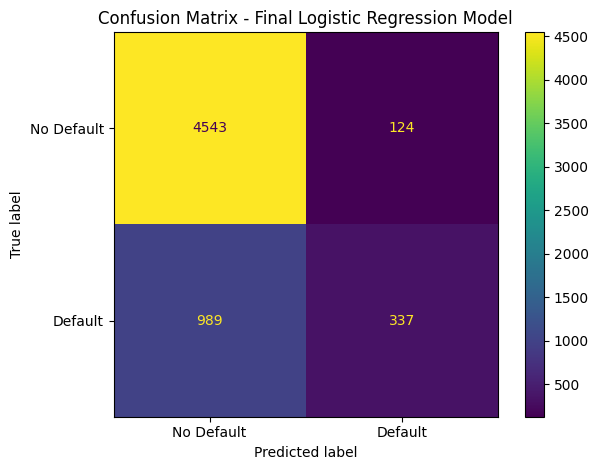

In [196]:
disp = ConfusionMatrixDisplay.from_predictions(y_test_1d, y_pred_final, display_labels=['No Default', 'Default'])

disp.plot

plt.title('Confusion Matrix - Final Logistic Regression Model')
plt.tight_layout()
plt.show()

In [197]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

In [198]:
final_accuracy = accuracy_score(y_test_1d, y_pred_final)
final_precision = precision_score(y_test_1d, y_pred_final)
final_recall = recall_score(y_test_1d, y_pred_final)
final_f1 = f1_score(y_test_1d, y_pred_final)
final_roc_auc = roc_auc_score(y_test_1d, y_prob_final)

In [199]:
final_metrics = pd.DataFrame({'metric': ['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
                             'score': [final_accuracy, final_precision, final_recall, final_f1, final_roc_auc]})

final_metrics

,metric,score
0,accuracy,0.814283
1,precision,0.731020
2,recall,0.254148
3,f1,0.377168
4,roc_auc,0.718685


In [200]:
from sklearn.metrics import classification_report

print(classification_report(y_test_1d, y_pred_final,
                            target_names=['No Default', 'Default']))

              precision    recall  f1-score   support

  No Default       0.82      0.97      0.89      4667
     Default       0.73      0.25      0.38      1326

    accuracy                           0.81      5993
   macro avg       0.78      0.61      0.63      5993
weighted avg       0.80      0.81      0.78      5993



In [201]:
from sklearn.metrics import roc_curve

In [202]:
fpr, tpr, thresholds = roc_curve(y_test_1d, y_prob_final)

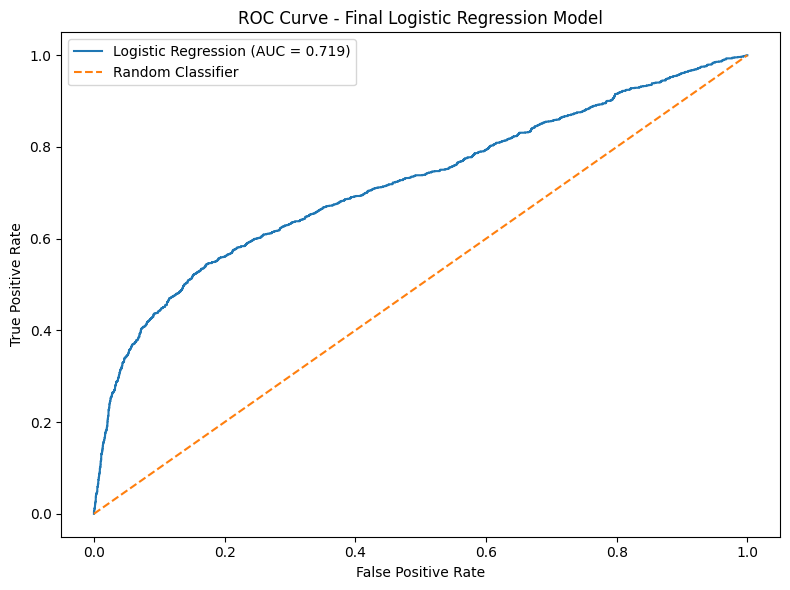

In [203]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {final_roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Final Logistic Regression Model')
plt.legend()
plt.tight_layout()
plt.show()

In [204]:
from sklearn.metrics import (precision_recall_curve, average_precision_score)

In [205]:
precision_values, recall_values, pr_thresholds = (precision_recall_curve(y_test_1d, y_prob_final))

average_precision = average_precision_score(y_test_1d, y_prob_final)

print("Average Precision:", average_precision)

Average Precision: 0.5057732961604535


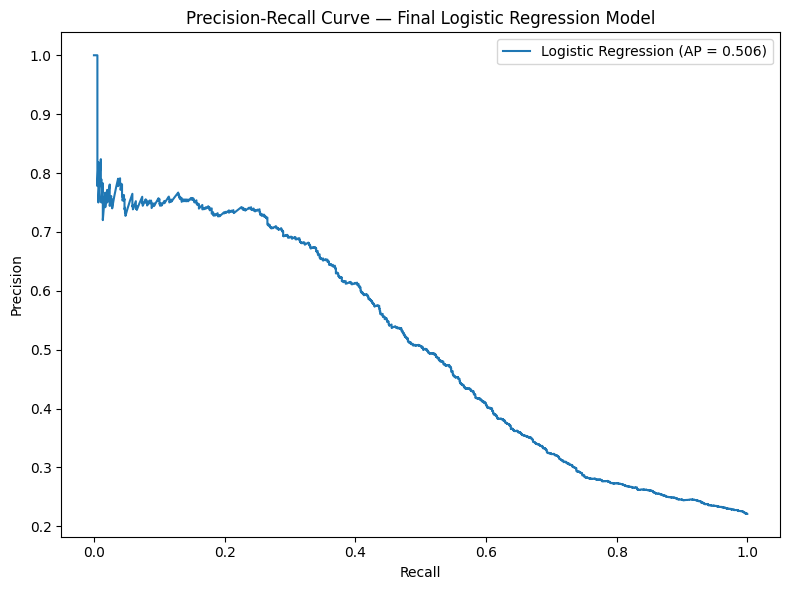

In [206]:
plt.figure(figsize=(8, 6))

plt.plot(recall_values, precision_values,
    label=f'Logistic Regression (AP = {average_precision:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Final Logistic Regression Model')
plt.legend()
plt.tight_layout()
plt.show()

In [207]:
prediction_results.groupby('actual')['default_probability'].describe()

,count,mean,std,min,25%,50%,75%,max
actual,,,,,,,,
0,4667.0,0.186741,0.118120,0.000241,0.107523,0.177994,0.233317,0.913962
1,1326.0,0.334731,0.205684,0.003577,0.169652,0.271497,0.503682,0.993049


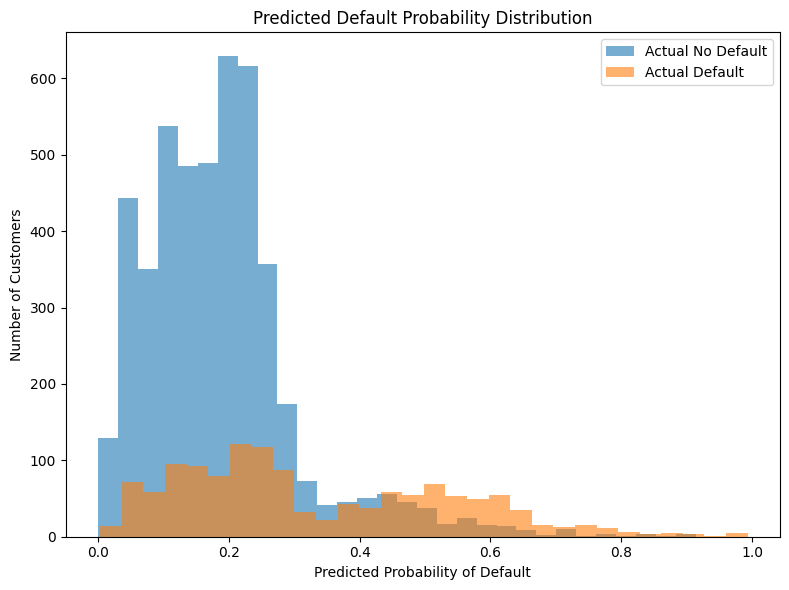

In [208]:
plt.figure(figsize=(8, 6))

plt.hist(prediction_results.loc[prediction_results['actual'] == 0,'default_probability'],
         bins=30, alpha=0.6, label='Actual No Default')

plt.hist(prediction_results.loc[prediction_results['actual'] == 1, 'default_probability'],
         bins=30, alpha=0.6, label='Actual Default')

plt.xlabel('Predicted Probability of Default')
plt.ylabel('Number of Customers')
plt.title('Predicted Default Probability Distribution')
plt.legend()
plt.tight_layout()
plt.show()

In [209]:
thresholds_to_test = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

In [210]:
threshold_results = []

for threshold in thresholds_to_test:

    predictions = (y_prob_final >= threshold).astype(int)

    threshold_results.append({'threshold': threshold,
                              'precision': precision_score(y_test_1d, predictions,
                                                           zero_division=0),
                              'recall': recall_score(y_test_1d, predictions,
                                                     zero_division=0),
                              'f1': f1_score(y_test_1d, predictions, zero_division=0),
                              'accuracy': accuracy_score(y_test_1d, predictions)})

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,threshold,precision,recall,f1,accuracy
0,0.20,0.329268,0.692308,0.446281,0.619890
1,0.25,0.453596,0.556561,0.499831,0.753546
2,0.30,0.555660,0.444193,0.493713,0.798432
3,0.35,0.597360,0.409502,0.485906,0.808276
4,0.40,0.631105,0.370287,0.466730,0.812782
5,0.45,0.681090,0.320513,0.435897,0.816453
6,0.50,0.731020,0.254148,0.377168,0.814283
7,0.55,0.737654,0.180241,0.289697,0.804439
8,0.60,0.757009,0.122172,0.210390,0.797097
9,0.65,0.743802,0.067873,0.124395,0.788587


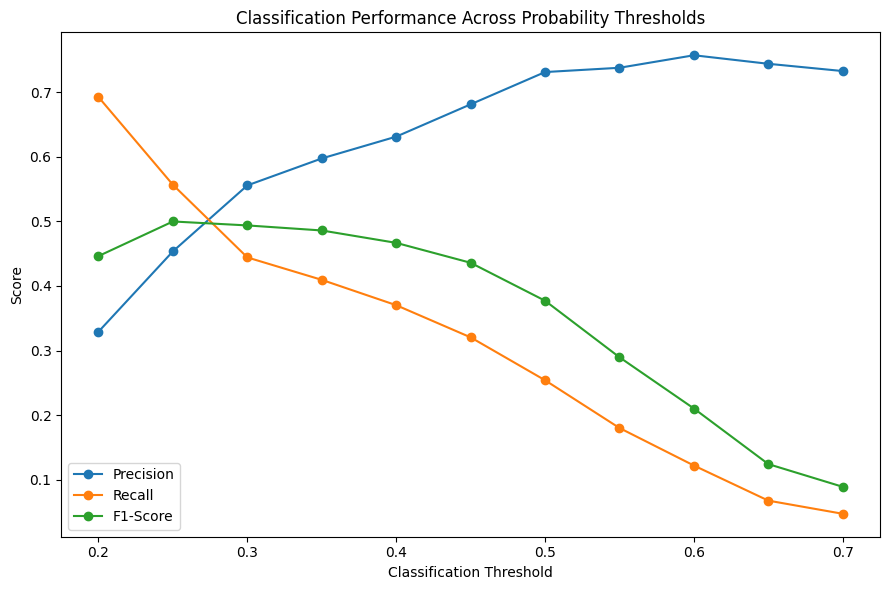

In [211]:
plt.figure(figsize=(9, 6))

plt.plot(threshold_results['threshold'], threshold_results['precision'],
         marker='o', label='Precision')

plt.plot(threshold_results['threshold'], threshold_results['recall'],
         marker='o', label='Recall')

plt.plot(threshold_results['threshold'], threshold_results['f1'], marker='o',
         label='F1-Score')

plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Classification Performance Across Probability Thresholds')
plt.legend()
plt.tight_layout()
plt.show()

In [212]:
best_threshold_row = (threshold_results.sort_values(by='f1', ascending=False).iloc[0])

best_threshold_row

,1
threshold,0.250000
precision,0.453596
recall,0.556561
f1,0.499831
accuracy,0.753546


In [213]:
print("Best threshold based on F1-score:", best_threshold_row['threshold'])

print("F1-score:", best_threshold_row['f1'])

Best threshold based on F1-score: 0.25
F1-score: 0.4998306806637318


In [214]:
prediction_results['correct'] = (prediction_results['actual']
                                 == prediction_results['predicted'])

In [215]:
false_positives = prediction_results[(prediction_results['actual'] == 0) &
 (prediction_results['predicted'] == 1)]

false_positives.head()

,actual,predicted,default_probability,correct
15,0,1,0.549288,False
18,0,1,0.510088,False
57,0,1,0.851411,False
69,0,1,0.636315,False
85,0,1,0.614959,False


In [216]:
print("False positives:", len(false_positives))

False positives: 124


In [217]:
false_negatives = prediction_results[(prediction_results['actual'] == 1) &
    (prediction_results['predicted'] == 0)]

false_negatives.head()

,actual,predicted,default_probability,correct
8,1,0,0.095173,False
17,1,0,0.304197,False
26,1,0,0.275408,False
34,1,0,0.163333,False
39,1,0,0.119184,False


In [218]:
print("False negatives:", len(false_negatives))

False negatives: 989


In [219]:
error_summary = pd.DataFrame({'error_type': ['False Positive', 'False Negative'],
                              'count': [len(false_positives), len(false_negatives)]})

error_summary

,error_type,count
0,False Positive,124
1,False Negative,989


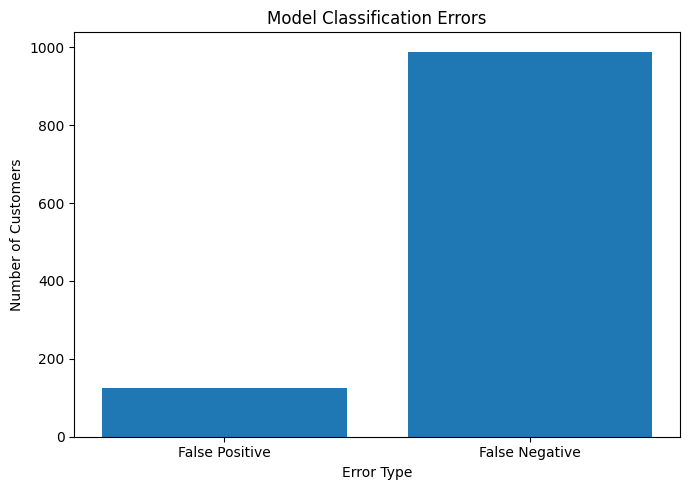

In [220]:
plt.figure(figsize=(7, 5))

plt.bar(error_summary['error_type'], error_summary['count'])

plt.xlabel('Error Type')
plt.ylabel('Number of Customers')
plt.title('Model Classification Errors')
plt.tight_layout()
plt.show()

In [221]:
final_coefficients

,feature,coefficient,odds_ratio,absolute_coefficient
21,categorical__marital_status_1,1.156048,3.177353,3.177353
23,categorical__marital_status_3,1.121370,3.069057,3.069057
22,categorical__marital_status_2,0.964444,2.623330,2.623330
19,categorical__education_5,-0.804570,0.447280,2.235735
18,categorical__education_4,-0.682931,0.505134,1.979673
24,remainder__repay_sep,0.578076,1.782605,1.782605
2,numerical__bill_amt_sep,-0.468108,0.626186,1.596969
20,categorical__education_6,-0.344564,0.708529,1.411375
15,categorical__education_1,0.317999,1.374375,1.374375
3,numerical__bill_amt_aug,0.286886,1.332272,1.332272


In [222]:
final_coefficients.head(20)

,feature,coefficient,odds_ratio,absolute_coefficient
21,categorical__marital_status_1,1.156048,3.177353,3.177353
23,categorical__marital_status_3,1.121370,3.069057,3.069057
22,categorical__marital_status_2,0.964444,2.623330,2.623330
19,categorical__education_5,-0.804570,0.447280,2.235735
18,categorical__education_4,-0.682931,0.505134,1.979673
24,remainder__repay_sep,0.578076,1.782605,1.782605
2,numerical__bill_amt_sep,-0.468108,0.626186,1.596969
20,categorical__education_6,-0.344564,0.708529,1.411375
15,categorical__education_1,0.317999,1.374375,1.374375
3,numerical__bill_amt_aug,0.286886,1.332272,1.332272


In [223]:
positive_effects = (final_coefficients[final_coefficients['coefficient'] > 0]
                    .sort_values(by='coefficient', ascending=False))

positive_effects.head(15)

,feature,coefficient,odds_ratio,absolute_coefficient
21,categorical__marital_status_1,1.156048,3.177353,3.177353
23,categorical__marital_status_3,1.121370,3.069057,3.069057
22,categorical__marital_status_2,0.964444,2.623330,2.623330
24,remainder__repay_sep,0.578076,1.782605,1.782605
15,categorical__education_1,0.317999,1.374375,1.374375
3,numerical__bill_amt_aug,0.286886,1.332272,1.332272
16,categorical__education_2,0.209737,1.233354,1.233354
17,categorical__education_3,0.170085,1.185405,1.185405
25,remainder__repay_aug,0.091911,1.096267,1.096267
7,numerical__bill_amt_apr,0.070197,1.072720,1.072720


In [224]:
negative_effects = (final_coefficients[final_coefficients['coefficient'] < 0]
                    .sort_values(by='coefficient'))

negative_effects.head(15)

,feature,coefficient,odds_ratio,absolute_coefficient
19,categorical__education_5,-0.804570,0.447280,2.235735
18,categorical__education_4,-0.682931,0.505134,1.979673
2,numerical__bill_amt_sep,-0.468108,0.626186,1.596969
20,categorical__education_6,-0.344564,0.708529,1.411375
8,numerical__pay_amt_sep,-0.259875,0.771148,1.296768
9,numerical__pay_amt_aug,-0.193508,0.824063,1.213500
14,categorical__sex_2,-0.103891,0.901324,1.109479
0,numerical__credit_limit,-0.097620,0.906993,1.102544
11,numerical__pay_amt_jun,-0.089066,0.914785,1.093153
12,numerical__pay_amt_may,-0.050434,0.950817,1.051728


In [225]:
odds_ratio_table = final_coefficients[['feature', 'coefficient', 'odds_ratio']].copy()

odds_ratio_table.head(20)

,feature,coefficient,odds_ratio
21,categorical__marital_status_1,1.156048,3.177353
23,categorical__marital_status_3,1.121370,3.069057
22,categorical__marital_status_2,0.964444,2.623330
19,categorical__education_5,-0.804570,0.447280
18,categorical__education_4,-0.682931,0.505134
24,remainder__repay_sep,0.578076,1.782605
2,numerical__bill_amt_sep,-0.468108,0.626186
20,categorical__education_6,-0.344564,0.708529
15,categorical__education_1,0.317999,1.374375
3,numerical__bill_amt_aug,0.286886,1.332272


In [226]:
cv_summary

,metric,mean_score,std_score
0,accuracy,0.809945,0.003321
1,precision,0.708215,0.025709
2,recall,0.240385,0.007812
3,f1,0.358832,0.010330
4,roc_auc,0.725144,0.011012


In [227]:
final_metrics

,metric,score
0,accuracy,0.814283
1,precision,0.731020
2,recall,0.254148
3,f1,0.377168
4,roc_auc,0.718685


In [228]:
cv_scores = cv_summary.set_index('metric')['mean_score']

performance_comparison = pd.DataFrame({'metric': ['Accuracy', 'Precision',
                                                  'Recall', 'F1', 'ROC-AUC'],
                                       'Cross_Validation_Mean': [cv_scores['accuracy'],
                                                                 cv_scores['precision'],
                                                                 cv_scores['recall'],
                                                                 cv_scores['f1'],
                                                                 cv_scores['roc_auc']],
                                       'Test_Set': [final_accuracy, final_precision,
                                                    final_recall, final_f1, final_roc_auc]})

performance_comparison

,metric,Cross_Validation_Mean,Test_Set
0,Accuracy,0.809945,0.814283
1,Precision,0.708215,0.731020
2,Recall,0.240385,0.254148
3,F1,0.358832,0.377168
4,ROC-AUC,0.725144,0.718685


In [229]:
final_evaluation_summary = pd.DataFrame({'Metric': ['Accuracy','Precision',
                                                    'Recall', 'F1-Score', 'ROC-AUC',
                                                    'Average Precision'],
                                         'Score': [final_accuracy, final_precision,
                                                   final_recall, final_f1, final_roc_auc,
                                                   average_precision]})

final_evaluation_summary

,Metric,Score
0,Accuracy,0.814283
1,Precision,0.731020
2,Recall,0.254148
3,F1-Score,0.377168
4,ROC-AUC,0.718685
5,Average Precision,0.505773


In [230]:
final_evaluation_summary.to_csv('final_model_evaluation.csv', index=False)

threshold_results.to_csv('threshold_analysis.csv', index=False)

odds_ratio_table.to_csv('logistic_regression_odds_ratios.csv', index=False)

## Milestone 7 Summary

The final Logistic Regression model was evaluated using the held-out test
dataset and multiple classification metrics.

A confusion matrix was used to identify true negatives, false positives,
false negatives, and true positives. Accuracy, precision, recall, F1-score,
and ROC-AUC were calculated to provide a comprehensive assessment of model
performance.

Because the target variable is imbalanced, particular attention was given
to recall, F1-score, ROC-AUC, and Precision-Recall analysis rather than
relying solely on accuracy.

The ROC curve and Precision-Recall curve were used to evaluate the model's
ability to distinguish between customers who defaulted and those who did
not default.

Predicted default probabilities were also examined to assess how the model
ranked customers according to estimated default risk. Multiple
classification thresholds were tested to demonstrate the trade-off between
precision and recall.

False-positive and false-negative predictions were analyzed to understand
the types of errors produced by the model. This analysis is particularly
important in credit-risk applications because incorrectly classifying a
future defaulter as a non-default customer may represent a more significant
risk than incorrectly classifying a non-default customer as high risk.

Finally, Logistic Regression coefficients and odds ratios were examined to
interpret the direction and relative strength of relationships between
predictors and default risk.

Cross-validation results were compared with held-out test-set performance
to assess model stability and generalization.

The completed evaluation provides a statistical and practical assessment
of the Logistic Regression model and establishes the basis for the final
model selection, conclusions, and portfolio documentation in Milestone 8.

## Milestone 8 — Final Model, Conclusions & Portfolio Documentation

### 8.1 Final Model Selection
- Confirm the selected Logistic Regression model
- Confirm the final regularization parameter
- Confirm the final preprocessing pipeline
- Confirm the final predictor set

### 8.2 Final Model Training
- Train the selected Logistic Regression model using the training dataset
- Generate final predictions and default probabilities
- Verify the final model outputs

### 8.3 Final Model Performance
- Report accuracy
- Report precision
- Report recall
- Report F1-score
- Report ROC-AUC
- Report Average Precision
- Compare cross-validation and test-set performance

### 8.4 Final Feature Importance
- Extract Logistic Regression coefficients
- Calculate odds ratios
- Rank predictors by absolute coefficient magnitude
- Identify predictors associated with increased default risk
- Identify predictors associated with decreased default risk

### 8.5 Risk Probability Analysis
- Examine predicted probabilities of default
- Identify high-risk probability ranges
- Analyze the relationship between predicted probability and actual default outcomes
- Summarize the model's ability to rank customers by estimated risk

### 8.6 Model Threshold Decision
- Review threshold analysis from Milestone 7
- Compare precision, recall, and F1-score across thresholds
- Select and document an appropriate analytical threshold
- Explain the trade-off between false positives and false negatives

### 8.7 Model Limitations
- Discuss class imbalance
- Discuss duplicate-record treatment
- Discuss limitations of Logistic Regression
- Discuss limitations of the available dataset
- Discuss potential effects of coded categorical and repayment variables
- Clarify that model relationships are predictive associations rather than causal relationships

### 8.8 Business Interpretation
- Explain how the model could support credit-risk screening
- Explain the importance of identifying potential default customers
- Discuss how predicted probabilities could support risk ranking
- Explain the implications of false positives and false negatives

### 8.9 Final Conclusions
- Summarize the main findings
- State whether the model achieved the project's objectives
- Identify the strongest predictors of default
- Evaluate the overall usefulness of the model

### 8.10 Portfolio Documentation
- Create a final project overview
- Document the dataset and methodology
- Document preprocessing and feature engineering
- Document model development
- Document evaluation results
- Document statistical interpretation
- Document limitations and future improvements

### 8.11 Export Final Results
- Save final evaluation metrics
- Save coefficient and odds-ratio tables
- Save threshold-analysis results
- Save prediction results
- Prepare final tables and figures for GitHub

### 8.12 Final Project Review
- Verify all code runs correctly
- Verify outputs are reproducible
- Remove unnecessary code
- Add clear Markdown explanations
- Check formatting and variable names
- Confirm the project is ready for GitHub publication

In [231]:
print("Final Logistic Regression Model")
print("-------------------------------")
print("C value:", best_c)
print("Maximum iterations:", final_logistic_model.max_iter)
print("Solver:", final_logistic_model.solver)

Final Logistic Regression Model
-------------------------------
C value: 100.0
Maximum iterations: 1000
Solver: lbfgs


In [232]:
y_pred_final = final_logistic_model.predict(x_test_processed).ravel()

y_prob_final = final_logistic_model.predict_proba(x_test_processed)[:, 1].ravel()

y_test_1d = np.asarray(y_test).ravel()

print("Actual values:", y_test_1d.shape)
print("Predicted classes:", y_pred_final.shape)
print("Predicted probabilities:", y_prob_final.shape)

Actual values: (5993,)
Predicted classes: (5993,)
Predicted probabilities: (5993,)


In [233]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score)

final_accuracy = accuracy_score(y_test_1d, y_pred_final)

final_precision = precision_score(y_test_1d, y_pred_final, zero_division=0)

final_recall = recall_score(y_test_1d, y_pred_final, zero_division=0)

final_f1 = f1_score(y_test_1d, y_pred_final, zero_division=0)

final_roc_auc = roc_auc_score(y_test_1d, y_prob_final)

final_average_precision = average_precision_score(y_test_1d, y_prob_final)

In [234]:
final_evaluation = pd.DataFrame({'Metric': ['Accuracy', 'Precision', 'Recall',
                                            'F1-Score', 'ROC-AUC',
                                            'Average Precision'],
                                 'Score': [final_accuracy, final_precision,
                                           final_recall, final_f1, final_roc_auc,
                                           final_average_precision]})

final_evaluation

,Metric,Score
0,Accuracy,0.814283
1,Precision,0.731020
2,Recall,0.254148
3,F1-Score,0.377168
4,ROC-AUC,0.718685
5,Average Precision,0.505773


In [235]:
final_evaluation_display = final_evaluation.copy()

final_evaluation_display['Score'] = (final_evaluation_display['Score'].round(4))

final_evaluation_display

,Metric,Score
0,Accuracy,0.8143
1,Precision,0.7310
2,Recall,0.2541
3,F1-Score,0.3772
4,ROC-AUC,0.7187
5,Average Precision,0.5058


In [236]:
cv_scores = cv_summary.set_index('metric')['mean_score']

In [237]:
performance_comparison = pd.DataFrame({'Metric': ['Accuracy','Precision','Recall',
                                                  'F1-Score','ROC-AUC'],
                                       'Cross-Validation Mean': [cv_scores['accuracy'],
                                                                 cv_scores['precision'],
                                                                 cv_scores['recall'],
                                                                 cv_scores['f1'],
                                                                 cv_scores['roc_auc']],
                                       'Test Set': [final_accuracy, final_precision,
                                                    final_recall, final_f1,
                                                    final_roc_auc]})

performance_comparison

,Metric,Cross-Validation Mean,Test Set
0,Accuracy,0.809945,0.814283
1,Precision,0.708215,0.731020
2,Recall,0.240385,0.254148
3,F1-Score,0.358832,0.377168
4,ROC-AUC,0.725144,0.718685


In [238]:
performance_comparison_display = performance_comparison.copy()

performance_comparison_display[
    ['Cross-Validation Mean', 'Test Set']] = performance_comparison_display[
        ['Cross-Validation Mean', 'Test Set']].round(4)

performance_comparison_display

,Metric,Cross-Validation Mean,Test Set
0,Accuracy,0.8099,0.8143
1,Precision,0.7082,0.7310
2,Recall,0.2404,0.2541
3,F1-Score,0.3588,0.3772
4,ROC-AUC,0.7251,0.7187


In [239]:
from sklearn.metrics import confusion_matrix

final_cm = confusion_matrix(y_test_1d, y_pred_final)

final_cm

array([[4543,  124],
       [ 989,  337]])

In [240]:
tn, fp, fn, tp = final_cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 4543
False Positives: 124
False Negatives: 989
True Positives: 337


In [241]:
confusion_summary = pd.DataFrame({'Outcome': ['True Negative', 'False Positive',
                                              'False Negative', 'True Positive'],
                                  'Count': [tn, fp, fn, tp]})

confusion_summary

,Outcome,Count
0,True Negative,4543
1,False Positive,124
2,False Negative,989
3,True Positive,337


In [242]:
from sklearn.metrics import classification_report

final_classification_report = classification_report(y_test_1d, y_pred_final,
                                                    target_names=['No Default',
                                                                  'Default'],
                                                    output_dict=True, zero_division=0)

classification_report_df = (pd.DataFrame(final_classification_report).transpose())

classification_report_df

,precision,recall,f1-score,support
No Default,0.821222,0.973430,0.890872,4667.000000
Default,0.731020,0.254148,0.377168,1326.000000
accuracy,0.814283,0.814283,0.814283,0.814283
macro avg,0.776121,0.613789,0.634020,5993.000000
weighted avg,0.801264,0.814283,0.777211,5993.000000


In [243]:
feature_names = preprocessor.get_feature_names_out()

final_coefficients = pd.DataFrame({'feature': feature_names,
                                   'coefficient': final_logistic_model.coef_[0]})

final_coefficients['absolute_coefficient'] = (final_coefficients['coefficient'].abs())

final_coefficients = (final_coefficients.sort_values(by='absolute_coefficient',
                                                     ascending=False))

final_coefficients.head(20)

,feature,coefficient,absolute_coefficient
21,categorical__marital_status_1,1.156048,1.156048
23,categorical__marital_status_3,1.121370,1.121370
22,categorical__marital_status_2,0.964444,0.964444
19,categorical__education_5,-0.804570,0.804570
18,categorical__education_4,-0.682931,0.682931
24,remainder__repay_sep,0.578076,0.578076
2,numerical__bill_amt_sep,-0.468108,0.468108
20,categorical__education_6,-0.344564,0.344564
15,categorical__education_1,0.317999,0.317999
3,numerical__bill_amt_aug,0.286886,0.286886


In [244]:
final_coefficients['odds_ratio'] = np.exp(final_coefficients['coefficient'])

final_coefficients.head(20)

,feature,coefficient,absolute_coefficient,odds_ratio
21,categorical__marital_status_1,1.156048,1.156048,3.177353
23,categorical__marital_status_3,1.121370,1.121370,3.069057
22,categorical__marital_status_2,0.964444,0.964444,2.623330
19,categorical__education_5,-0.804570,0.804570,0.447280
18,categorical__education_4,-0.682931,0.682931,0.505134
24,remainder__repay_sep,0.578076,0.578076,1.782605
2,numerical__bill_amt_sep,-0.468108,0.468108,0.626186
20,categorical__education_6,-0.344564,0.344564,0.708529
15,categorical__education_1,0.317999,0.317999,1.374375
3,numerical__bill_amt_aug,0.286886,0.286886,1.332272


In [245]:
final_coefficients = final_coefficients[['feature', 'coefficient', 'odds_ratio',
                                         'absolute_coefficient']]

final_coefficients.head(20)

,feature,coefficient,odds_ratio,absolute_coefficient
21,categorical__marital_status_1,1.156048,3.177353,1.156048
23,categorical__marital_status_3,1.121370,3.069057,1.121370
22,categorical__marital_status_2,0.964444,2.623330,0.964444
19,categorical__education_5,-0.804570,0.447280,0.804570
18,categorical__education_4,-0.682931,0.505134,0.682931
24,remainder__repay_sep,0.578076,1.782605,0.578076
2,numerical__bill_amt_sep,-0.468108,0.626186,0.468108
20,categorical__education_6,-0.344564,0.708529,0.344564
15,categorical__education_1,0.317999,1.374375,0.317999
3,numerical__bill_amt_aug,0.286886,1.332272,0.286886


In [246]:
higher_default_risk = (final_coefficients[final_coefficients['coefficient'] > 0].sort_values(
    by='coefficient',ascending=False))

higher_default_risk.head(15)

,feature,coefficient,odds_ratio,absolute_coefficient
21,categorical__marital_status_1,1.156048,3.177353,1.156048
23,categorical__marital_status_3,1.121370,3.069057,1.121370
22,categorical__marital_status_2,0.964444,2.623330,0.964444
24,remainder__repay_sep,0.578076,1.782605,0.578076
15,categorical__education_1,0.317999,1.374375,0.317999
3,numerical__bill_amt_aug,0.286886,1.332272,0.286886
16,categorical__education_2,0.209737,1.233354,0.209737
17,categorical__education_3,0.170085,1.185405,0.170085
25,remainder__repay_aug,0.091911,1.096267,0.091911
7,numerical__bill_amt_apr,0.070197,1.072720,0.070197


In [247]:
lower_default_risk = (final_coefficients[final_coefficients['coefficient'] < 0].sort_values(
    by='coefficient', ascending=True))

lower_default_risk.head(15)

,feature,coefficient,odds_ratio,absolute_coefficient
19,categorical__education_5,-0.804570,0.447280,0.804570
18,categorical__education_4,-0.682931,0.505134,0.682931
2,numerical__bill_amt_sep,-0.468108,0.626186,0.468108
20,categorical__education_6,-0.344564,0.708529,0.344564
8,numerical__pay_amt_sep,-0.259875,0.771148,0.259875
9,numerical__pay_amt_aug,-0.193508,0.824063,0.193508
14,categorical__sex_2,-0.103891,0.901324,0.103891
0,numerical__credit_limit,-0.097620,0.906993,0.097620
11,numerical__pay_amt_jun,-0.089066,0.914785,0.089066
12,numerical__pay_amt_may,-0.050434,0.950817,0.050434


In [248]:
odds_ratio_summary = final_coefficients[['feature', 'coefficient', 'odds_ratio']].copy()

odds_ratio_summary['coefficient'] = (odds_ratio_summary['coefficient'].round(4))

odds_ratio_summary['odds_ratio'] = (odds_ratio_summary['odds_ratio'].round(4))

odds_ratio_summary.head(20)

,feature,coefficient,odds_ratio
21,categorical__marital_status_1,1.1560,3.1774
23,categorical__marital_status_3,1.1214,3.0691
22,categorical__marital_status_2,0.9644,2.6233
19,categorical__education_5,-0.8046,0.4473
18,categorical__education_4,-0.6829,0.5051
24,remainder__repay_sep,0.5781,1.7826
2,numerical__bill_amt_sep,-0.4681,0.6262
20,categorical__education_6,-0.3446,0.7085
15,categorical__education_1,0.3180,1.3744
3,numerical__bill_amt_aug,0.2869,1.3323


In [249]:
final_predictions = pd.DataFrame({'actual_default': y_test_1d,
                                  'predicted_default': y_pred_final,
                                  'predicted_default_probability': y_prob_final})

final_predictions['correct_prediction'] = (final_predictions['actual_default']
                                           == final_predictions['predicted_default'])

final_predictions.head(10)

,actual_default,predicted_default,predicted_default_probability,correct_prediction
0,0,0,0.236015,True
1,0,0,0.185954,True
2,0,0,0.227005,True
3,0,0,0.222405,True
4,0,0,0.171672,True
5,0,0,0.128899,True
6,0,0,0.271386,True
7,0,0,0.164022,True
8,1,0,0.095173,False
9,0,0,0.040256,True


In [250]:
high_risk_customers = final_predictions[final_predictions[
    'predicted_default_probability'] >= 0.70].copy()

print("Number of high-risk customers:", len(high_risk_customers))

high_risk_customers.head(10)

Number of high-risk customers: 86


,actual_default,predicted_default,predicted_default_probability,correct_prediction
42,1,1,0.719988,True
46,1,1,0.723456,True
57,0,1,0.851411,False
172,0,1,0.730049,False
196,0,1,0.702372,False
473,0,1,0.723286,False
567,1,1,0.748021,True
590,1,1,0.910451,True
631,1,1,0.966716,True
682,1,1,0.864322,True


In [251]:
final_predictions['risk_group'] = pd.cut(final_predictions['predicted_default_probability'],
                                         bins=[0, 0.25, 0.50, 0.75, 1.00],
                                         labels=['Low','Moderate','High','Very High'],
                                         include_lowest=True)

In [252]:
final_predictions['risk_group'].value_counts(sort=False)

,count
risk_group,
Low,4366
Moderate,1166
High,407
Very High,54


In [253]:
risk_group_analysis = (final_predictions.groupby('risk_group', observed=False).agg(
    customers=('actual_default', 'size'), actual_defaults=('actual_default', 'sum'),
    average_predicted_probability=('predicted_default_probability', 'mean')))

risk_group_analysis['actual_default_rate'] = (risk_group_analysis['actual_defaults']
                                              / risk_group_analysis['customers'])

risk_group_analysis

,customers,actual_defaults,average_predicted_probability,actual_default_rate
risk_group,,,,
Low,4366,588,0.145814,0.134677
Moderate,1166,401,0.337933,0.343911
High,407,296,0.588564,0.727273
Very High,54,41,0.836553,0.759259


In [254]:
threshold_results

,threshold,precision,recall,f1,accuracy
0,0.20,0.329268,0.692308,0.446281,0.619890
1,0.25,0.453596,0.556561,0.499831,0.753546
2,0.30,0.555660,0.444193,0.493713,0.798432
3,0.35,0.597360,0.409502,0.485906,0.808276
4,0.40,0.631105,0.370287,0.466730,0.812782
5,0.45,0.681090,0.320513,0.435897,0.816453
6,0.50,0.731020,0.254148,0.377168,0.814283
7,0.55,0.737654,0.180241,0.289697,0.804439
8,0.60,0.757009,0.122172,0.210390,0.797097
9,0.65,0.743802,0.067873,0.124395,0.788587


In [255]:
best_threshold_row = (threshold_results.sort_values(by='f1', ascending=False).iloc[0])

print("Best analytical threshold:", best_threshold_row['threshold'])

print("F1-score:", best_threshold_row['f1'])

print("Precision:", best_threshold_row['precision'])

print("Recall:", best_threshold_row['recall'])

Best analytical threshold: 0.25
F1-score: 0.4998306806637318
Precision: 0.4535955746773202
Recall: 0.5565610859728507


In [256]:
best_threshold = best_threshold_row['threshold']

y_pred_threshold = (y_prob_final >= best_threshold).astype(int)

threshold_confusion_matrix = confusion_matrix(y_test_1d, y_pred_threshold)

threshold_confusion_matrix

array([[3778,  889],
       [ 588,  738]])

In [257]:
threshold_precision = precision_score(y_test_1d, y_pred_threshold, zero_division=0)

threshold_recall = recall_score(y_test_1d, y_pred_threshold, zero_division=0)

threshold_f1 = f1_score(y_test_1d, y_pred_threshold, zero_division=0)

threshold_accuracy = accuracy_score(y_test_1d, y_pred_threshold)

threshold_metrics = pd.DataFrame({'Metric': ['Accuracy', 'Precision', 'Recall',
                                             'F1-Score'],
                                  'Score': [threshold_accuracy, threshold_precision,
                                            threshold_recall, threshold_f1]})

threshold_metrics

,Metric,Score
0,Accuracy,0.753546
1,Precision,0.453596
2,Recall,0.556561
3,F1-Score,0.499831


In [258]:
final_model_statistics = pd.DataFrame({'Statistic': ['Training observations',
                                                     'Testing observations',
                                                     'Number of predictors',
                                                     'Best C value', 'Accuracy',
                                                     'Precision','Recall','F1-Score',
                                                     'ROC-AUC', 'Average Precision',
                                                     'True Negatives','False Positives',
                                                     'False Negatives','True Positives'],
                                       'Value': [len(y_train), len(y_test_1d),
                                                 x_train_processed.shape[1], best_c,
                                                 final_accuracy, final_precision,
                                                 final_recall, final_f1, final_roc_auc,
                                                 final_average_precision,
                                                 tn, fp, fn, tp]})

final_model_statistics

,Statistic,Value
0,Training observations,23972.000000
1,Testing observations,5993.000000
2,Number of predictors,30.000000
3,Best C value,100.000000
4,Accuracy,0.814283
5,Precision,0.731020
6,Recall,0.254148
7,F1-Score,0.377168
8,ROC-AUC,0.718685
9,Average Precision,0.505773


In [259]:
final_evaluation.to_csv('final_evaluation_metrics.csv', index=False)

performance_comparison.to_csv('cv_vs_test_performance.csv', index=False)

confusion_summary.to_csv('confusion_matrix_results.csv', index=False)

odds_ratio_summary.to_csv('logistic_regression_odds_ratios.csv', index=False)

final_predictions.to_csv('final_predictions.csv', index=False)

risk_group_analysis.to_csv('risk_group_analysis.csv')

threshold_results.to_csv('threshold_analysis.csv', index=False)

final_model_statistics.to_csv('final_model_statistics.csv', index=False)

In [260]:
import os

exported_files = ['final_evaluation_metrics.csv', 'cv_vs_test_performance.csv',
                  'confusion_matrix_results.csv', 'logistic_regression_odds_ratios.csv',
                  'final_predictions.csv', 'risk_group_analysis.csv',
                  'threshold_analysis.csv', 'final_model_statistics.csv']

for file in exported_files:
    print(file, "—", "Created" if os.path.exists(file) else "Missing")

final_evaluation_metrics.csv — Created
cv_vs_test_performance.csv — Created
confusion_matrix_results.csv — Created
logistic_regression_odds_ratios.csv — Created
final_predictions.csv — Created
risk_group_analysis.csv — Created
threshold_analysis.csv — Created
final_model_statistics.csv — Created


In [261]:
print("FINAL PROJECT CHECK")
print("-------------------")

print("Dataset shape:", df.shape)
print("Training observations:", len(y_train))
print("Testing observations:", len(y_test_1d))
print("Processed training features:", x_train_processed.shape)
print("Processed testing features:", x_test_processed.shape)

print("\nFinal Model")
print("C:", best_c)

print("\nFinal Performance")
print("Accuracy:", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall:", round(final_recall, 4))
print("F1-Score:", round(final_f1, 4))
print("ROC-AUC:", round(final_roc_auc, 4))
print("Average Precision:", round(final_average_precision, 4))

print("\nConfusion Matrix")
print(final_cm)

FINAL PROJECT CHECK
-------------------
Dataset shape: (29965, 24)
Training observations: 23972
Testing observations: 5993
Processed training features: (23972, 30)
Processed testing features: (5993, 30)

Final Model
C: 100.0

Final Performance
Accuracy: 0.8143
Precision: 0.731
Recall: 0.2541
F1-Score: 0.3772
ROC-AUC: 0.7187
Average Precision: 0.5058

Confusion Matrix
[[4543  124]
 [ 989  337]]


## Milestone 8 Summary

The final Logistic Regression model was selected and documented based on
cross-validation and held-out test-set performance.

The final model was evaluated using accuracy, precision, recall, F1-score,
ROC-AUC, and Average Precision. A confusion matrix was also used to examine
true-positive, true-negative, false-positive, and false-negative
predictions.

Model coefficients and odds ratios were analyzed to identify predictors
associated with higher or lower estimated default risk. These relationships
were interpreted as predictive associations rather than causal effects.

Predicted probabilities of default were analyzed to assess the model's
ability to rank customers according to estimated credit risk. Customers
were also grouped into probability-based risk categories to examine whether
higher predicted risk corresponded to higher observed default rates.

Classification threshold analysis demonstrated the trade-off between
precision and recall and showed that the default classification threshold
can affect the model's practical performance.

Cross-validation results were compared with held-out test-set results to
assess model stability and generalization. The final results provide a
comprehensive evaluation of the model's predictive performance.

Several limitations were identified, including class imbalance, the
limitations of the available dataset, the interpretation of coded
repayment-history variables, and the limitations of Logistic Regression as
a linear classification method.

Overall, the project demonstrates an end-to-end credit-risk modeling
workflow using Python, Pandas, and Scikit-Learn, including data inspection,
exploratory analysis, preprocessing, feature scaling, categorical
encoding, multicollinearity assessment, Logistic Regression, regularization,
cross-validation, probability-based classification, model evaluation, and
statistical interpretation.

The completed project is now ready for final GitHub documentation,
visualization selection, and portfolio presentation.